# EDA

In [44]:
train_size = 0.70

In [45]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('imgs', exist_ok=True)


In [46]:
# # if files are on drive
# from google.colab import drive
# drive.mount('/content/drive')
# data = pd.read_csv('/content/drive/MyDrive/ai in industry/raw_sales.csv')
# income = pd.read_csv('/content/drive/MyDrive/ai in industry/MEHOINUSA672N.csv')
# mortgage = pd.read_csv('/content/drive/MyDrive/ai in industry/MORTGAGE15US.csv')

In [47]:
data = pd.read_csv('raw_sales.csv')
mortgage = pd.read_csv('MORTGAGE15US.csv')
income = pd.read_csv('MEHOINUSA672N.csv')
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [48]:
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [49]:
mortgage.head()

,observation_date,MORTGAGE15US
0,2007-02-08,6.02
1,2007-02-15,6.03
2,2007-02-22,5.97
3,2007-03-01,5.92
4,2007-03-08,5.86


In [50]:
income.head()

,observation_date,MEHOINUSA672N
0,2007-01-01,73010
1,2008-01-01,70520
2,2009-01-01,70070
3,2010-01-01,68420
4,2011-01-01,67410


In [51]:
# mortgage is weekly and income is yearly. make both of them monthly.
# for mortgage, average the weeks within each month; for income, forward fill the yearly value to all months.
mortgage['observation_date'] = pd.to_datetime(mortgage['observation_date'])
mortgage_monthly = (
    mortgage
    .set_index('observation_date')
    .resample('M')   # month-end
    .mean()
    .reset_index()
)

income['observation_date'] = pd.to_datetime(income['observation_date'])
income_monthly = (
    income
    .set_index('observation_date')
    .resample('M')   # month-end
    .ffill()
    .reset_index()
)

mortgage_monthly.head()

,observation_date,MORTGAGE15US
0,2007-02-28,6.006667
1,2007-03-31,5.884000
2,2007-04-30,5.882500
3,2007-05-31,5.968000
4,2007-06-30,6.340000


In [52]:
income_monthly.head()

,observation_date,MEHOINUSA672N
0,2007-01-31,73010
1,2007-02-28,73010
2,2007-03-31,73010
3,2007-04-30,73010
4,2007-05-31,73010


In [53]:
df = data.copy()
df = df.rename(columns={'datesold': 'date', 'propertyType': 'type'})
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,postcode,price,type,bedrooms
0,2007-02-07,2607,525000,house,4
1,2007-02-27,2906,290000,house,3
2,2007-03-07,2905,328000,house,3
3,2007-03-09,2905,380000,house,4
4,2007-03-21,2906,310000,house,3


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      29580 non-null  datetime64[ns]
 1   postcode  29580 non-null  int64         
 2   price     29580 non-null  int64         
 3   type      29580 non-null  object        
 4   bedrooms  29580 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


type
house    647956.128462
unit     423106.557279
Name: price, dtype: float64


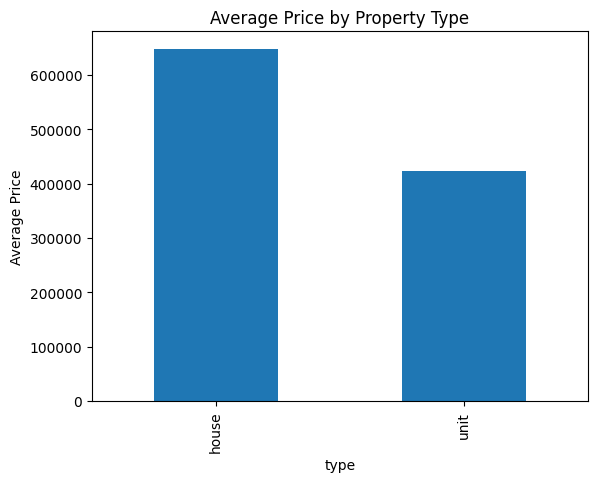

In [55]:
avg_price_by_type = df.groupby('type')['price'].mean().sort_values(ascending=False)
print(avg_price_by_type)
avg_price_by_type.plot(kind='bar', title='Average Price by Property Type')
plt.ylabel('Average Price')
plt.savefig('./imgs/avg_price_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

bedrooms
5    919056.058974
4    718171.142023
3    552304.428140
0    542300.000000
2    442222.917454
1    335992.905962
Name: price, dtype: float64


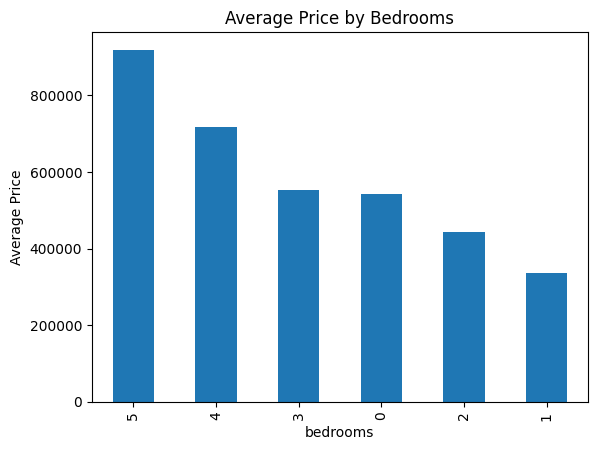

In [56]:
avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)
print(avg_price_by_bedrooms)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.savefig('./imgs/avg_price_by_bedrooms.png', dpi=150, bbox_inches='tight')
plt.show()

# MISSING VALUES

The number of bedrooms 0 can be considered as missing values, as it is unlikely that a property would have zero bedrooms. It is possible that these entries were either not recorded correctly. To handle these missing values, we can either impute them with a reasonable value (such as the median number of bedrooms for that property type) or we can choose to drop those rows from the dataset if they are not significant in number.

In [57]:
#check for missing values
print(df.isnull().sum())

date        0
postcode    0
price       0
type        0
bedrooms    0
dtype: int64


In [58]:
# KNNImputer

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

def imputer_pipeline(df):

    df2 = df.copy()

    df2['bedrooms'] = df2['bedrooms'].replace(0, np.nan)

    # One-hot encode 'type' instead of label encoding
    type_dummies = pd.get_dummies(df2['type'], prefix='type')
    df2 = pd.concat([df2, type_dummies], axis=1)

    features = ['price', 'bedrooms'] + list(type_dummies.columns)
    X = df2[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    imputer = KNNImputer(n_neighbors=5, weights='distance')
    X_imputed = imputer.fit_transform(X_scaled)
    X_unscaled = scaler.inverse_transform(X_imputed)

    df2['bedrooms'] = X_unscaled[:, 1]
    df2['bedrooms'] = df2['bedrooms'].round().astype(int)
    df2['bedrooms'] = df2['bedrooms'].clip(lower=1, upper=5)

    # Drop the temporary one-hot columns
    df2 = df2.drop(columns=list(type_dummies.columns))

    return df2

In [59]:
# print the different values that bedrooms assumes when type == 'unit'
print(df[df['type'] == 'unit']['bedrooms'].unique())

[2 3 1 0 4 5]


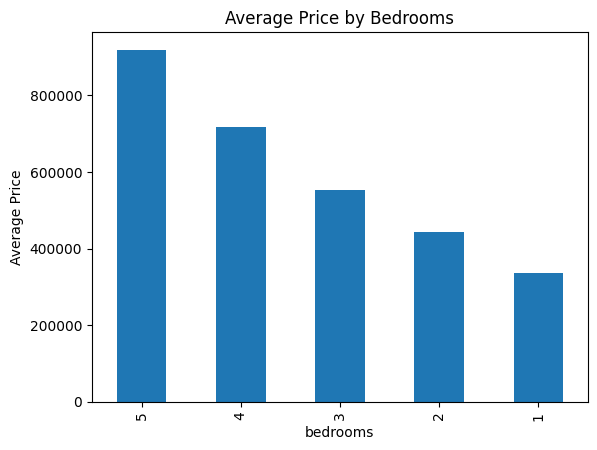

In [60]:
df = imputer_pipeline(df)

avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.savefig('./imgs/avg_price_by_bedrooms_imputed.png', dpi=150, bbox_inches='tight')
plt.show()

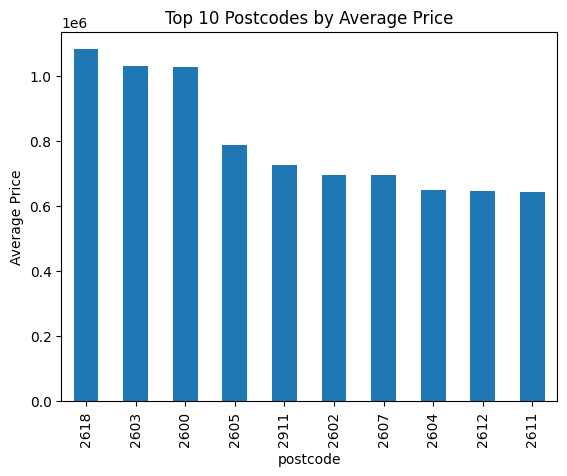

In [21]:
avg_price_by_postcode = df.groupby('postcode')['price'].mean().sort_values(ascending=False).head(10)

avg_price_by_postcode.plot(kind='bar', title='Top 10 Postcodes by Average Price')
plt.ylabel('Average Price')
plt.savefig('./imgs/top10_postcodes_avg_price.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
df.columns

Index(['date', 'postcode', 'price', 'type', 'bedrooms', 'type_encoded'], dtype='object')

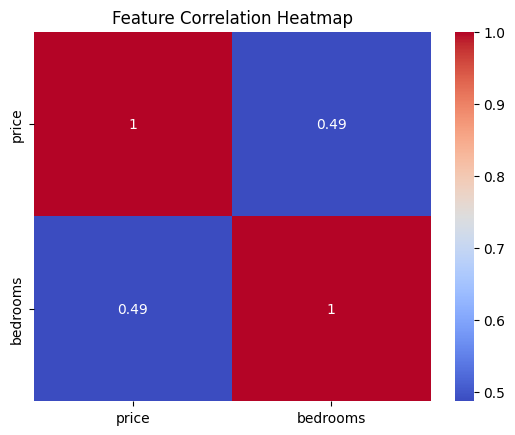

In [23]:
numeric_features = ['price', 'bedrooms']
sns.heatmap(df[numeric_features].corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('./imgs/feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The fact that the correlation between price and bedrooms is 0.49 suggests that there is a moderate positive relationship between the two variables. This means that, in general, as the number of bedrooms increases, the price tends to increase as well. However, it is not a very strong correlation, indicating that there are other factors influencing the price of the properties besides just the number of bedrooms.

# OUTLIERS

In [24]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1 # interquartile range, which is the difference between the 75th percentile (Q3) and the 25th percentile (Q1)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#for example, 

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Outliers detected: {len(outliers)}")

Outliers detected: 1374


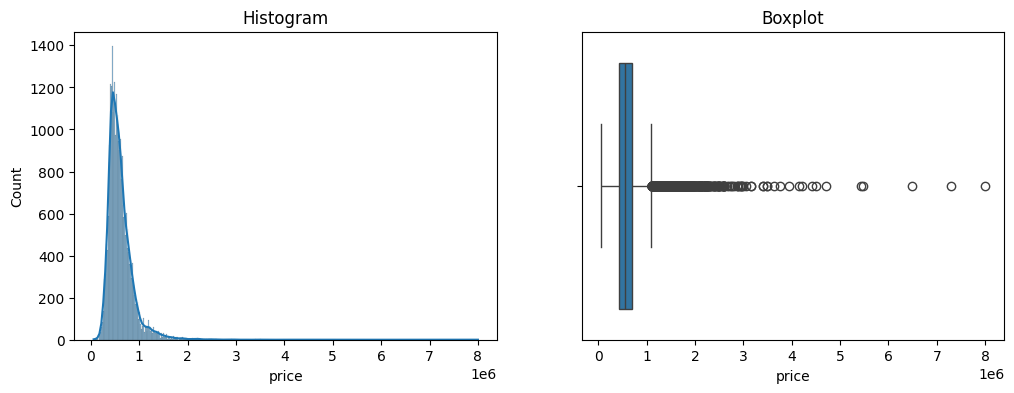

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_distribution(df, column):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[column], kde=True, ax=ax[0])
    ax[0].set_title("Histogram")

    sns.boxplot(x=df[column], ax=ax[1])
    ax[1].set_title("Boxplot")

    plt.savefig(f'./imgs/distribution_{column}.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_distribution(df, 'price')

Since it's right skewed, we can apply a log transformation to the price variable to make it more normally distributed. This can help improve the performance of certain machine learning algorithms that assume normality in the data, such as linear regression. After applying the log transformation, we can visualize the distribution again to confirm that it has become more normal.

In [26]:
def plot_price_distribution(df, method):
    plt.figure(figsize=(10, 6))
    sns.histplot(df['price'], kde=True)
    plt.title('Distribution of Property Prices')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(f'./imgs/price_distribution_{method}.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_price_trend(monthly):
    plt.figure(figsize=(12, 6))
    plt.plot(monthly.index, monthly['price'], color='lightgray', label='Original', linewidth=1.5)
    plt.plot(monthly.index, monthly['price_rolling'], color='blue', label='Smoothed', linewidth=2)
    plt.title('Median Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Median Price')
    plt.legend()
    plt.tight_layout()
    plt.savefig('./imgs/price_trend.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_monthly_trend(monthly_df):
    monthly_df[['price', 'avg_bedrooms', 'house_ratio', 'sales_count']].plot(
        subplots=True, figsize=(10, 8), title='Monthly Trends')
    plt.tight_layout()
    plt.savefig('./imgs/monthly_trends.png', dpi=150, bbox_inches='tight')
    plt.show()

In [27]:
from sklearn.preprocessing import PowerTransformer

def pipeline(df, type_of_outlier, plotting=True):
    # Three strategies for right-skewed outliers:
    # 'none'            – keep data as-is
    # 'remove'          – drop rows outside IQR bounds
    # 'log_transform'   – apply log to price
    # 'power_transform' – Box-Cox transform

    if type_of_outlier == 'none':
        df_cleaned = df.copy()

    elif type_of_outlier == 'remove':
        Q1 = df['price'].quantile(0.25)
        Q3 = df['price'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_cleaned = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

    elif type_of_outlier == 'log_transform':
        df_cleaned = df.copy()
        df_cleaned['price'] = np.log(df_cleaned['price'])

    elif type_of_outlier == 'power_transform':
        df_cleaned = df.copy()
        pt = PowerTransformer(method='box-cox')
        df_cleaned['price'] = pt.fit_transform(df_cleaned[['price']])

    if plotting:
        plot_price_distribution(df_cleaned, type_of_outlier)

    monthly = df_cleaned.resample('M', on='date').agg({'price': 'median'})
    monthly['price_rolling'] = monthly['price'].rolling(window=3, center=True).mean() # 3-month rolling average for smoothing

    if plotting:
        plot_price_trend(monthly)

    df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
    df_cleaned['month'] = df_cleaned['date'].dt.to_period('M')

    monthly_df = (
        df_cleaned.groupby('month').agg(
            price=('price', 'median'),
            house_ratio=('type', lambda x: (x == 'house').mean()),
            avg_bedrooms=('bedrooms', 'mean'),
            sales_count=('price', 'count')
        )
        .reset_index()
    )

    monthly_df['month'] = monthly_df['month'].dt.to_timestamp()
    monthly_df.set_index('month', inplace=True)

        # Merge macroeconomic monthly features (mortgage & income) into monthly_df if available
    try:
        macro_mortgage = mortgage_monthly.copy()
        macro_mortgage = macro_mortgage.rename(
            columns={
                'observation_date': 'month',
                'MORTGAGE15US': 'mortgage_rate'
            }
        )
        macro_mortgage['month'] = (
            pd.to_datetime(macro_mortgage['month'])
            .dt.to_period('M')
            .dt.to_timestamp()
        )
        macro_mortgage.set_index('month', inplace=True)

        macro_income = income_monthly.copy()
        macro_income = macro_income.rename(
            columns={
                'observation_date': 'month',
                'MEHOINUSA672N': 'median_income'
            }
        )
        macro_income['month'] = (
            pd.to_datetime(macro_income['month'])
            .dt.to_period('M')
            .dt.to_timestamp()
        )
        macro_income.set_index('month', inplace=True)

        macro = macro_mortgage.join(macro_income, how='outer')

        # join on the monthly index and forward-fill missing macro values
        monthly_df = monthly_df.join(
            macro[['mortgage_rate', 'median_income']],
            how='left'
        )
        monthly_df[['mortgage_rate', 'median_income']] = (
            monthly_df[['mortgage_rate', 'median_income']].ffill()
        )
    except NameError:
        # macro data not loaded, proceed without these features
        pass

    if plotting:
        plot_monthly_trend(monthly_df)

    return df_cleaned, monthly, monthly_df

df_cleaned, monthly, monthly_df = pipeline(df, type_of_outlier='remove', plotting=False)


The reason why we need house_ratio (house_ratio=('type', lambda x: (x == 'house').mean())) is to calculate the proportion of properties that are classified as 'house' within each month. This can provide insights into the distribution of property types over time and how it may relate to price trends. By including this ratio in our analysis, we can better understand the composition of the housing market and how it may influence median prices.

# TRENDS AND SEASONALITY DECOMPOSITION

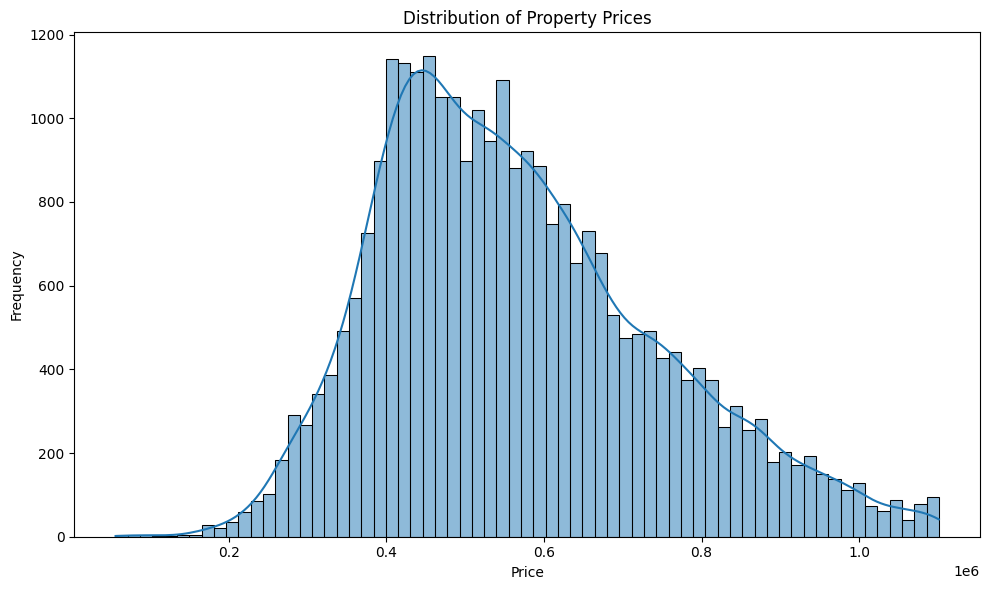

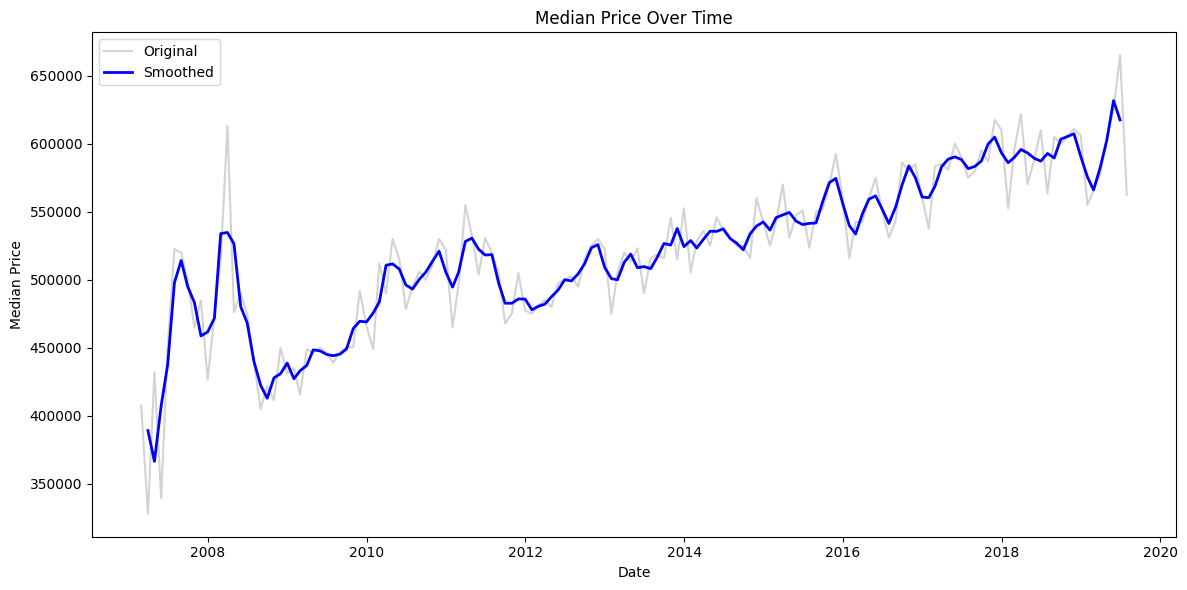

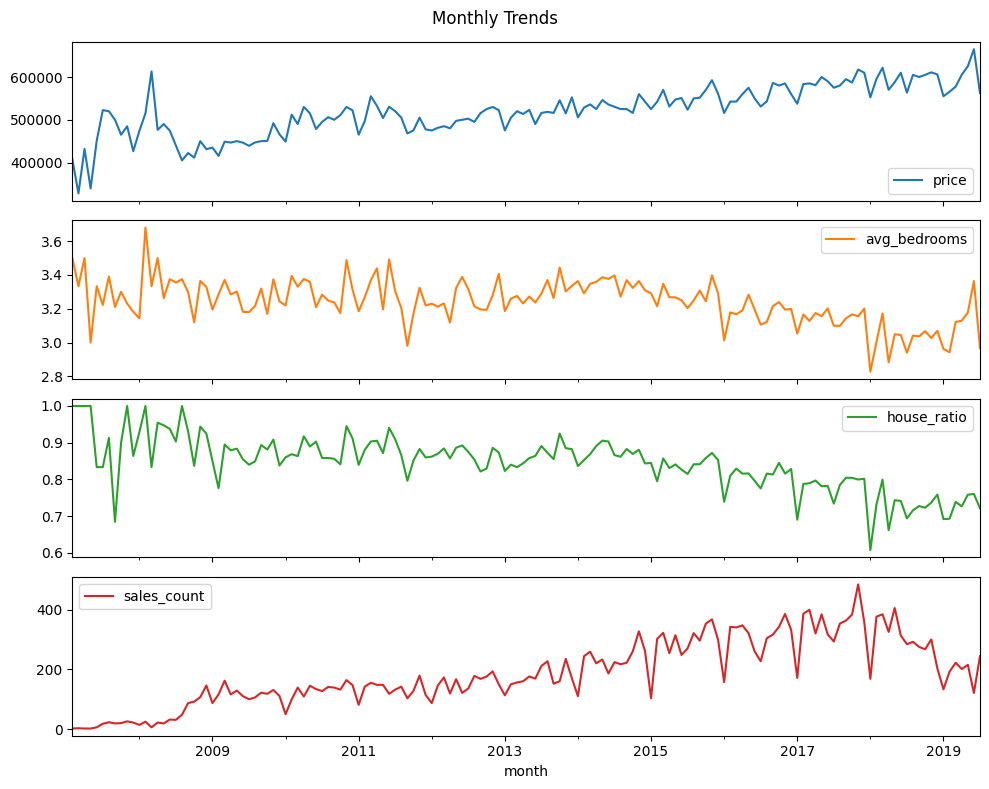

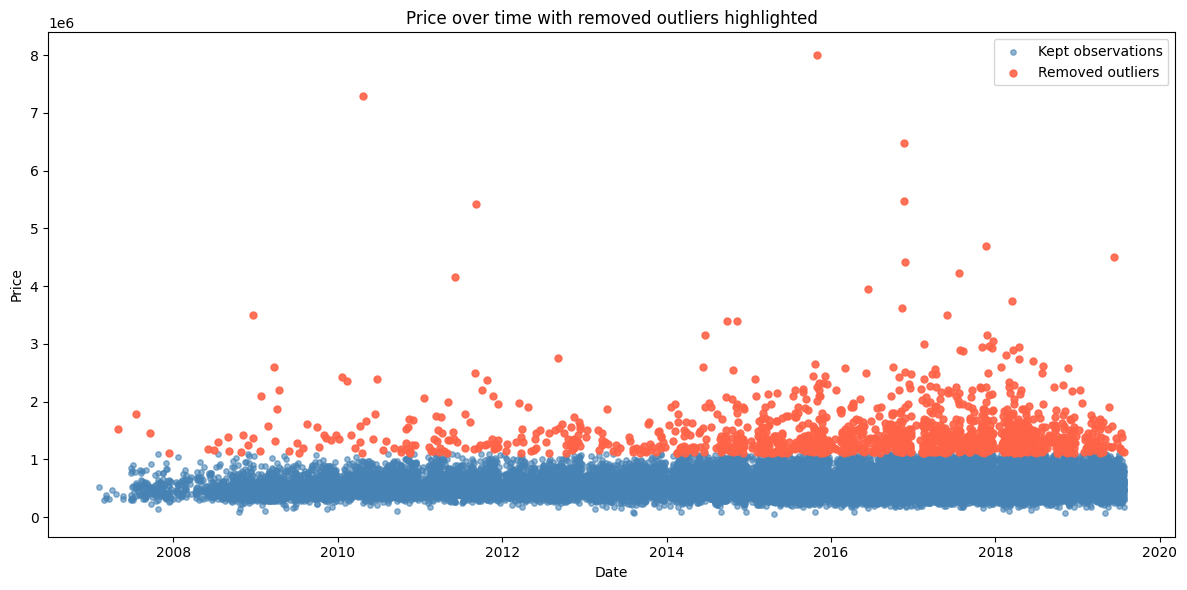

,price,house_ratio,avg_bedrooms,sales_count,mortgage_rate,median_income
month,,,,,,
2007-02-01,407500.0,1.000000,3.500000,2,6.006667,73010.0
2007-03-01,328000.0,1.000000,3.333333,3,5.884000,73010.0
2007-04-01,432000.0,1.000000,3.500000,2,5.882500,73010.0
2007-05-01,339500.0,1.000000,3.000000,2,5.968000,73010.0
2007-06-01,451000.0,0.833333,3.333333,6,6.340000,73010.0


In [28]:
df_cleaned, monthly, monthly_df = pipeline(df, type_of_outlier='remove', plotting=True)

# Recompute the same IQR bounds used inside pipeline
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Points that were removed as outliers
mask_outlier = (df['price'] < lower_bound) | (df['price'] > upper_bound)
df_removed = df[mask_outlier]

# Time–price plot with different colours
plt.figure(figsize=(12, 6))

plt.scatter(
    df_cleaned['date'],
    df_cleaned['price'],
    s=15,
    alpha=0.6,
    color='steelblue',
    label='Kept observations',
)

plt.scatter(
    df_removed['date'],
    df_removed['price'],
    s=25,
    alpha=0.9,
    color='tomato',
    label='Removed outliers',
)

plt.title('Price over time with removed outliers highlighted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.savefig('./imgs/price_over_time_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

monthly_df.head()

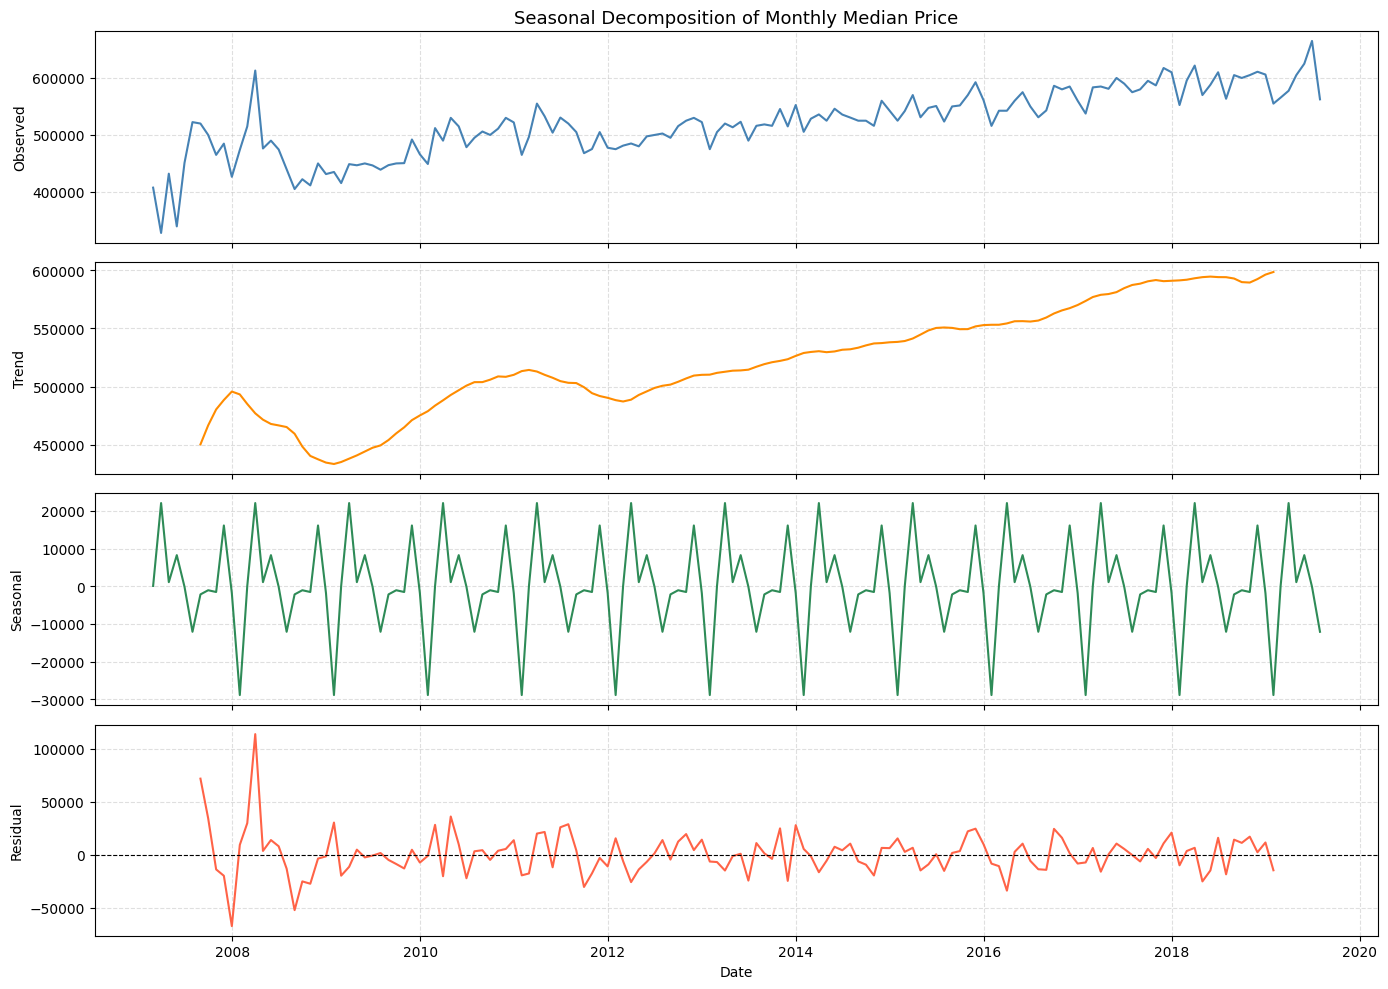

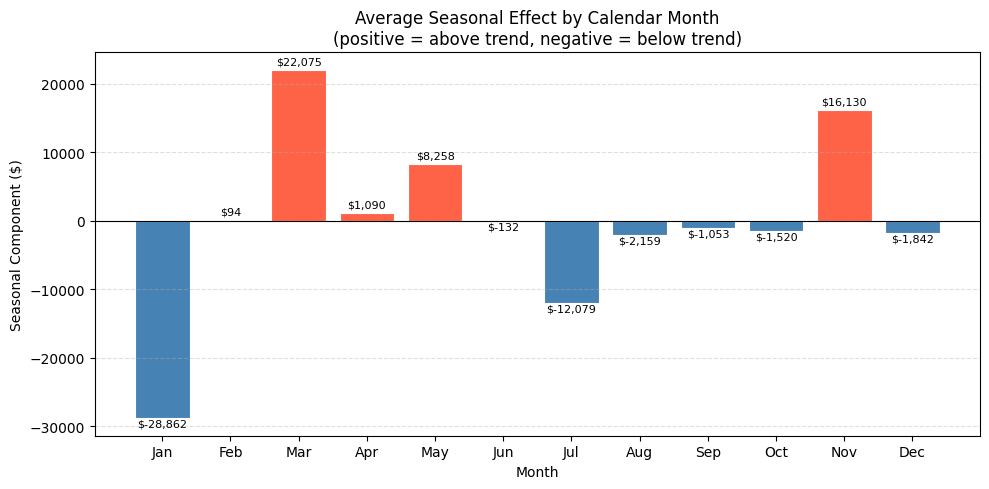

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose
import calendar

decomposition = seasonal_decompose(monthly['price'], model='additive', period=12)

# ── 1. Full decomposition plot (improved) ────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

components = {
    'Observed':  decomposition.observed,
    'Trend':     decomposition.trend,
    'Seasonal':  decomposition.seasonal,
    'Residual':  decomposition.resid,
}

colors = ['steelblue', 'darkorange', 'seagreen', 'tomato']

for ax, (name, series), color in zip(axes, components.items(), colors):
    ax.plot(series.index, series.values, color=color, linewidth=1.5)
    ax.set_ylabel(name, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    if name == 'Residual':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

axes[0].set_title('Seasonal Decomposition of Monthly Median Price', fontsize=13)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('./imgs/seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Average seasonal pattern by calendar month ────────────────────────────
seasonal_by_month = (
    decomposition.seasonal
    .groupby(decomposition.seasonal.index.month)
    .mean()
)
seasonal_by_month.index = [calendar.month_abbr[m] for m in seasonal_by_month.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    seasonal_by_month.index,
    seasonal_by_month.values,
    color=['tomato' if v > 0 else 'steelblue' for v in seasonal_by_month.values],
    edgecolor='white',
    linewidth=0.8,
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Seasonal Effect by Calendar Month\n(positive = above trend, negative = below trend)', fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Seasonal Component ($)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Annotate bars
for bar, val in zip(bars, seasonal_by_month.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + (500 if val >= 0 else -1500),
        f'${val:,.0f}',
        ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()
plt.savefig('./imgs/seasonal_pattern_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

As we can see in our plot, most of the house prices range between $300,000 and $800,000.

There appears to be something interesting going on at the beginning of the time series plot. There is a very sharp peak around 2007 to 2008, with a major spike much higher than anything around it. This is in fact the observation with the highest price in the entire time series plot, reaching up to $800,000, so this is something of interest from the data. After doing some research, there was a major financial crisis which occurred from 2007 to 2008 which marked a huge economic recession. It would make sense that a big financial crisis like this would also have a significant effect on the housing market, so this is likely why there is such a sharp and sudden peak in home sale prices around 2007 to 2008.

There does appear to be some sort of seasonal trend going on within the data as seen by the various peaks and drops that can be seen within the plot. This shows evidence of some sort of seasonality occurring. This seasonal pattern appears to repeat over each year, with the highest and lowest peaks occurring within the span of each year period.

A seasonal trend would make sense for a data set relating to house sale prices as the time of year could affect the number of individuals buying a new home, and thus sale prices rising to meet this larger demand. For instance, times of year such as the summer may see an increase of buyers looking for a new house due to the ideal weather and the timing of summer break making it ideal to buy a house before the next school year begins if the buyers have children. This greater demand could lead to a rise in the sales prices of the homes, and could be a potential explanation for this seasonal trend we see in the time series plot.

Additionally, there appears to be an overall increase in home sale prices from 2007 to 2019. Looking at the trend curve, we can see that there has been an overall, gradual increase in the home sale prices from the start of this data set’s collection to the end of its collection. So, we can conclude that the home sale prices have gradually increased from what they were in 2007 to what they became in 2019.

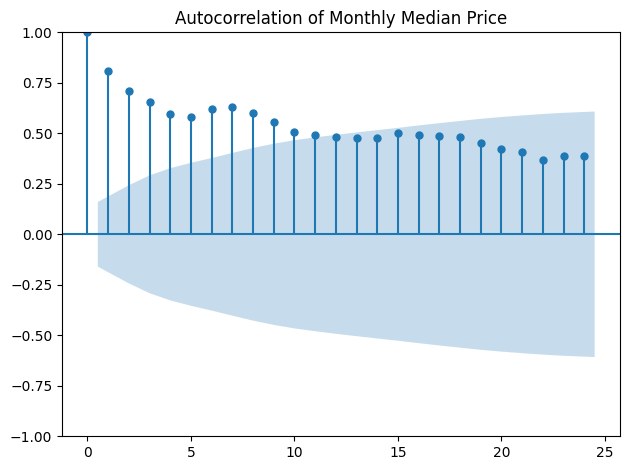

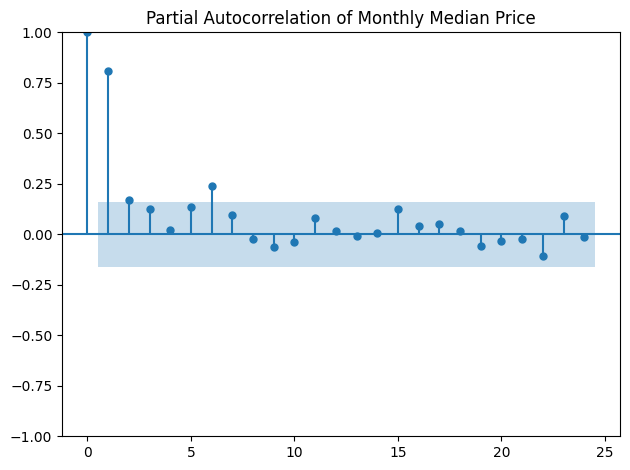

In [30]:
# plot autocorrelation and partial autocorrelation
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(monthly['price'].dropna(), lags=24)
plt.title('Autocorrelation of Monthly Median Price')
plt.tight_layout()
plt.savefig('./imgs/acf.png', dpi=150, bbox_inches='tight')
plt.show()
plot_pacf(monthly['price'].dropna(), lags=24)
plt.title('Partial Autocorrelation of Monthly Median Price')
plt.tight_layout()
plt.savefig('./imgs/pacf.png', dpi=150, bbox_inches='tight')
plt.show()

**Strong Trend (Non-Stationarity)**: The most prominent feature is the slow, gradual decay of the autocorrelation values starting from lag 0. This is a textbook signature of a non-stationary time series with a strong underlying trend. It means the price in any given month is heavily tethered to the prices in the immediately preceding months.

**Significant Lags**: The shaded blue cone represents the confidence interval. Any point (stem) that falls outside this cone is statistically significant. Lags 1 through roughly 9 remain above the blue area, indicating that historical prices up to 9 months back have a mathematically significant relationship with the current price.

Difference between autocorrelation and partial autocorrelation: The autocorrelation function (ACF) measures the correlation between the time series and its own lagged values, while the partial autocorrelation function (PACF) measures the correlation between the time series and its lagged values after controlling for the effects of intermediate lags. In other words, ACF captures both direct and indirect relationships, while PACF isolates the direct relationship at each lag.

In [31]:
monthly_df.head(20)

,price,house_ratio,avg_bedrooms,sales_count,mortgage_rate,median_income
month,,,,,,
2007-02-01,407500.0,1.000000,3.500000,2,6.006667,73010.0
2007-03-01,328000.0,1.000000,3.333333,3,5.884000,73010.0
2007-04-01,432000.0,1.000000,3.500000,2,5.882500,73010.0
2007-05-01,339500.0,1.000000,3.000000,2,5.968000,73010.0
2007-06-01,451000.0,0.833333,3.333333,6,6.340000,73010.0
2007-07-01,522500.0,0.833333,3.222222,18,6.360000,73010.0
2007-08-01,520000.0,0.913043,3.391304,23,6.234000,73010.0
2007-09-01,500000.0,0.684211,3.210526,19,6.047500,73010.0
2007-10-01,465000.0,0.900000,3.300000,20,6.040000,73010.0


# GEOGRAPHIC ANALYSIS

In [32]:
# print average house price vs average unit price
avg_price_by_type = df.groupby('type')['price'].mean()
print(avg_price_by_type)

type
house    647956.128462
unit     423106.557279
Name: price, dtype: float64


In [33]:
# Calculate the historical average price per postcode
zone_prices = df.groupby('postcode')['price'].median().sort_values(ascending=False)

# Define 'Premium' zones (e.g., top 25% of postcodes by price)
premium_cutoff = zone_prices.quantile(0.65)
premium_postcodes = zone_prices[zone_prices >= premium_cutoff].index.tolist()

# Create a 'is_premium_zone' feature
df['is_premium_zone'] = df['postcode'].isin(premium_postcodes).astype(int)

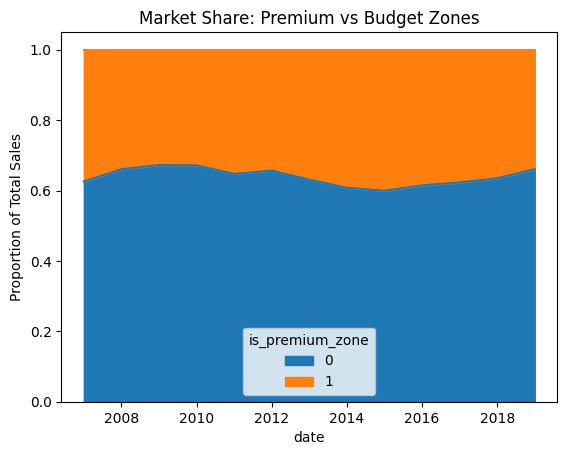

In [34]:
# Group by year and zone type to see volume trends
zone_trends = df.groupby([df['date'].dt.year, 'is_premium_zone']).size().unstack()
zone_trends_pct = zone_trends.div(zone_trends.sum(axis=1), axis=0)

zone_trends_pct.plot(kind='area', stacked=True, title='Market Share: Premium vs Budget Zones')
plt.ylabel('Proportion of Total Sales')
plt.savefig('./imgs/market_share_premium_budget.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# 1. Calculate the historical median price per postcode to identify expensive areas
postcode_stats = df.groupby('postcode')['price'].median().sort_values(ascending=False)

# 2. Define 'Premium' zones as the top 25% most expensive postcodes
premium_cutoff = postcode_stats.quantile(0.75)
premium_postcodes = postcode_stats[postcode_stats >= premium_cutoff].index.tolist()

# 3. Tag each sale in the main dataframe
df['zone_type'] = df['postcode'].apply(lambda x: 'Premium' if x in premium_postcodes else 'Budget')

print(f"Premium Zone Cutoff: ${premium_cutoff:,.0f}")
print(f"Number of Premium Postcodes: {len(premium_postcodes)}")

Premium Zone Cutoff: $643,000
Number of Premium Postcodes: 7


In [36]:
# Create a 'year' column for grouping
df['year'] = df['date'].dt.year

# Calculate volume share per year per zone
zone_distribution = df.groupby(['year', 'zone_type']).size().unstack().fillna(0)

# Convert to percentages (normalized)
zone_share_pct = zone_distribution.divide(zone_distribution.sum(axis=1), axis=0) * 100

# Display the trend table
print(zone_share_pct.tail())

zone_type     Budget    Premium
year                           
2015       76.781798  23.218202
2016       78.659161  21.340839
2017       79.938340  20.061660
2018       81.855884  18.144116
2019       83.104693  16.895307


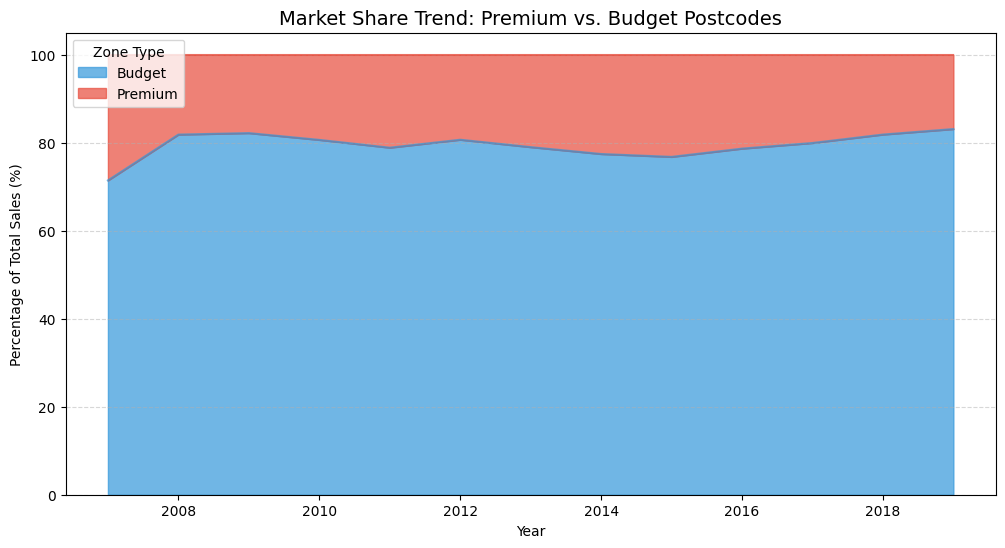

In [37]:
plt.figure(figsize=(12, 6))
zone_share_pct.plot(kind='area', stacked=True, color=['#3498db', '#e74c3c'], alpha=0.7, ax=plt.gca())

plt.title('Market Share Trend: Premium vs. Budget Postcodes', fontsize=14)
plt.ylabel('Percentage of Total Sales (%)')
plt.xlabel('Year')
plt.legend(title='Zone Type', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('./imgs/market_share_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# MEDIAN PRICE BY MONTH FORECAST WITH ML MODELS

## Seasonality Feature Engineering

Before fitting any model, we enrich `monthly_df` with three new columns that encode temporal patterns:

- **`month_sin` / `month_cos`** — Cyclical encoding of the month number.  
  A raw integer (1–12) would imply that December and January are 11 steps apart, when they are actually adjacent.  
  Projecting onto the unit circle (`sin(2π·m/12)`, `cos(2π·m/12)`) preserves the cyclic structure and uniquely identifies every month.

  Source: https://www.kaggle.com/code/avanwyk/encoding-cyclical-features-for-deep-learning/code

- **`year_scaled`** — Mean-centred, unit-variance year. Captures the long-run upward price trend without dominating gradient-based optimisers (important for the LSTM).

In [38]:
def add_seasonality_features(monthly_df: pd.DataFrame) -> pd.DataFrame:
    """
    Append cyclical month encoding and scaled year to a monthly DatetimeIndex DataFrame.
    - month_sin / month_cos : encode the cyclic structure of the 12-month calendar
    - year_scaled           : linear trend proxy (zero-mean, unit-variance)
    """
    df = monthly_df.copy()
    month = df.index.month
    # Convert to a NumPy array so mean/std are always available
    year  = np.asarray(df.index.year, dtype=float)

    df['month_sin']   = np.sin(2 * np.pi * month / 12)
    df['month_cos']   = np.cos(2 * np.pi * month / 12)
    year_mean = year.mean()
    year_std  = year.std() if year.std() != 0 else 1.0
    df['year_scaled'] = (year - year_mean) / year_std
    return df

# Quick sanity check
_,_,_tmp = pipeline(df, type_of_outlier='remove', plotting=False)
print(add_seasonality_features(_tmp).head())

               price  house_ratio  avg_bedrooms  sales_count  mortgage_rate  \
month                                                                         
2007-02-01  407500.0     1.000000      3.500000            2       6.006667   
2007-03-01  328000.0     1.000000      3.333333            3       5.884000   
2007-04-01  432000.0     1.000000      3.500000            2       5.882500   
2007-05-01  339500.0     1.000000      3.000000            2       5.968000   
2007-06-01  451000.0     0.833333      3.333333            6       6.340000   

            median_income     month_sin     month_cos  year_scaled  
month                                                               
2007-02-01        73010.0  8.660254e-01  5.000000e-01    -1.613876  
2007-03-01        73010.0  1.000000e+00  6.123234e-17    -1.613876  
2007-04-01        73010.0  8.660254e-01 -5.000000e-01    -1.613876  
2007-05-01        73010.0  5.000000e-01 -8.660254e-01    -1.613876  
2007-06-01        73010.0  1.224

In [39]:
#print for every month the month_sin value, to show how it captures the cyclical nature of months
seasonal_df = add_seasonality_features(_tmp)
print(seasonal_df[['month_sin', 'month_cos']].head(12))

               month_sin     month_cos
month                                 
2007-02-01  8.660254e-01  5.000000e-01
2007-03-01  1.000000e+00  6.123234e-17
2007-04-01  8.660254e-01 -5.000000e-01
2007-05-01  5.000000e-01 -8.660254e-01
2007-06-01  1.224647e-16 -1.000000e+00
2007-07-01 -5.000000e-01 -8.660254e-01
2007-08-01 -8.660254e-01 -5.000000e-01
2007-09-01 -1.000000e+00 -1.836970e-16
2007-10-01 -8.660254e-01  5.000000e-01
2007-11-01 -5.000000e-01  8.660254e-01
2007-12-01 -2.449294e-16  1.000000e+00
2008-01-01  5.000000e-01  8.660254e-01


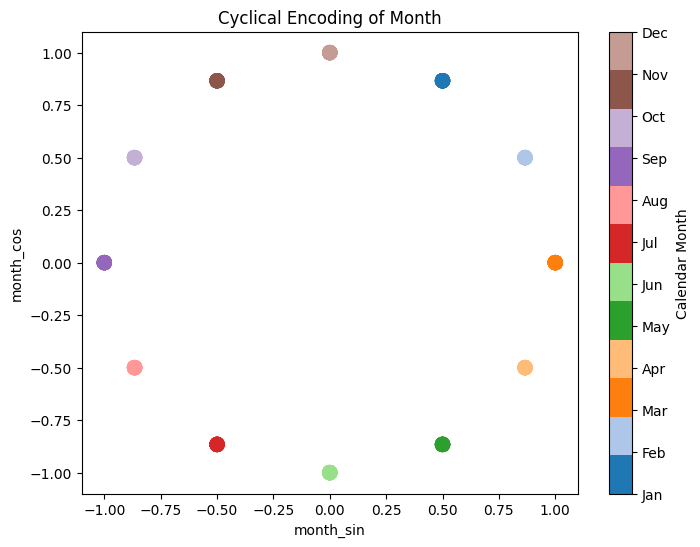

In [40]:
from matplotlib.colors import ListedColormap

# plot sin(month) and cos(month) to show the cyclical encoding
monthly_df_with_seasonality = add_seasonality_features(monthly_df)

months = monthly_df_with_seasonality.index.month
cmap = ListedColormap(plt.cm.tab20.colors[:12])  # 12 distinct colors

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    monthly_df_with_seasonality['month_sin'],
    monthly_df_with_seasonality['month_cos'],
    c=months,
    cmap=cmap,
    s=100,
    vmin=1,
    vmax=12,
)
plt.xlabel('month_sin')
plt.ylabel('month_cos')
plt.title('Cyclical Encoding of Month')

cbar = plt.colorbar(sc, ticks=np.arange(1, 13))
cbar.ax.set_yticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
cbar.set_label('Calendar Month')

plt.savefig('./imgs/cyclical_encoding_month.png', dpi=150, bbox_inches='tight')
plt.show()

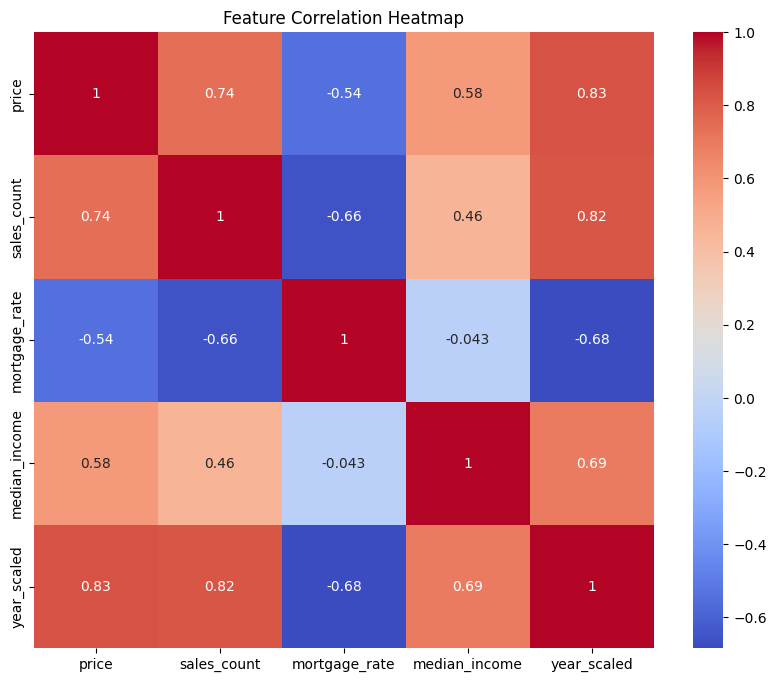

In [41]:
# let's check the correlation of the new features with price
_,_,monthly_df = pipeline(df, type_of_outlier='remove', plotting=False)
monthly_df = add_seasonality_features(monthly_df)
numeric_features = [
    'price',
    #'house_ratio',
    #'avg_bedrooms',
    'sales_count',
    'mortgage_rate',
    'median_income',
    #'month_sin',
    #'month_cos',
    'year_scaled',
]

plt.figure(figsize=(10, 8))
plt.title('Feature Correlation Heatmap')
sns.heatmap(monthly_df[numeric_features].corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.savefig('./imgs/feature_correlation_heatmap_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

### Random Forest Regressor

**Feature importance note:** The three original features (`sales_count`, `avg_bedrooms`, `house_ratio`) remain the dominant predictors.  
The seasonality features (`month_sin`, `month_cos`, `year_scaled`) should absorb some of the variance that was previously captured implicitly by `sales_count` (which itself is seasonal), potentially improving generalisation.  
The SHAP beeswarm additionally shows the *direction* of each feature's effect: positive SHAP values push the predicted price up, negative values push it down.

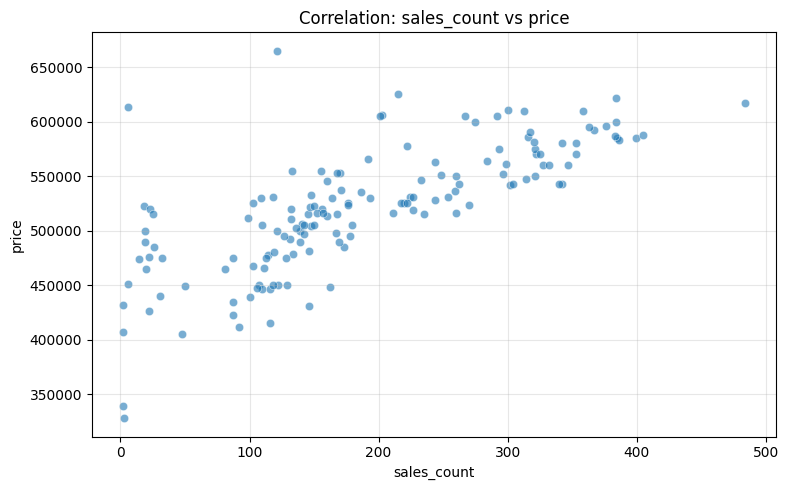

In [39]:
# Correlation scatter plots (fix: save BEFORE show)
df_corr, _, monthly_corr = pipeline(df, type_of_outlier='remove', plotting=False)
monthly_corr_season = add_seasonality_features(monthly_corr)

def plot_correlation(df, feature, target='price'):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[feature], y=df[target], alpha=0.6)
    plt.title(f'Correlation: {feature} vs {target}')
    plt.xlabel(feature); plt.ylabel(target)
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f'./imgs/correlation_random_forest_{feature}_{target}.png', dpi=150, bbox_inches='tight')  # save BEFORE show
    plt.show()

for feat in ['sales_count']:# 'avg_bedrooms', 'house_ratio', 'month_sin', 'month_cos', 'year_scaled']:
    plot_correlation(monthly_corr_season, feat, target='price')

Average Price in the Last 15% of Time Series:
type
house    734103.534926
unit     417444.223395
Name: price, dtype: float64


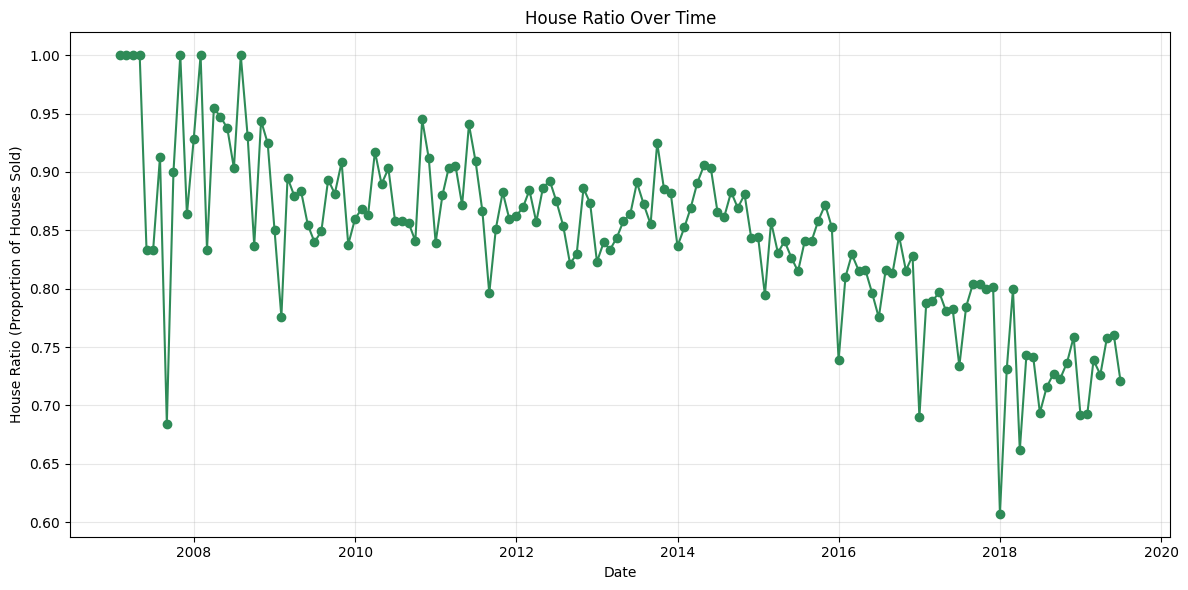

In [40]:
# print the average house price vs average unit price in the last 15% of the time series

def print_prices(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    cutoff_date = df['date'].quantile(0.85)
    recent_df = df[df['date'] >= cutoff_date]
    avg_price_by_type = recent_df.groupby('type')['price'].mean()
    print("Average Price in the Last 15% of Time Series:")
    print(avg_price_by_type)

print_prices(df)

# since house costs more than unit, we expect house ratio (i.e. proportion of houses to total 
# buildings) to be correlated with price

#plot house_ratio in time
_, _, monthly_trend = pipeline(df, type_of_outlier='remove', plotting=False)
plt.figure(figsize=(12, 6))
plt.plot(monthly_trend.index, monthly_trend['house_ratio'], marker='o', color='seagreen')
plt.title('House Ratio Over Time')
plt.xlabel('Date')
plt.ylabel('House Ratio (Proportion of Houses Sold)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./imgs/house_ratio_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

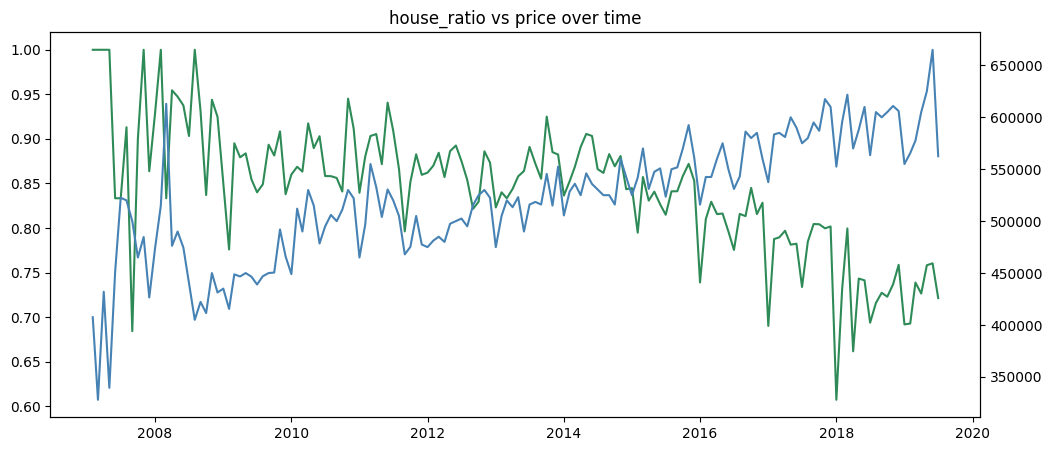

In [41]:
# Quick diagnostic — check house_ratio trend over time
_, _, monthly_df_check = pipeline(df, type_of_outlier='remove', plotting=False)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly_df_check.index, monthly_df_check['house_ratio'], color='seagreen', label='house_ratio')
ax2 = ax1.twinx()
ax2.plot(monthly_df_check.index, monthly_df_check['price'], color='steelblue', label='price')
plt.title('house_ratio vs price over time')
plt.show()

Total combinations to evaluate: 1023
Evaluating features: ['month_sin'] ...
Evaluating features: ['month_cos'] ...
Evaluating features: ['year_scaled'] ...
Evaluating features: ['avg_bedrooms'] ...
Evaluating features: ['house_ratio'] ...
Evaluating features: ['sales_count'] ...
Evaluating features: ['mortgage_rate'] ...
Evaluating features: ['median_income'] ...
Evaluating features: ['price_lag_1'] ...
Evaluating features: ['price_lag_12'] ...
Evaluating features: ['month_sin', 'month_cos'] ...
Evaluating features: ['month_sin', 'year_scaled'] ...
Evaluating features: ['month_sin', 'avg_bedrooms'] ...
Evaluating features: ['month_sin', 'house_ratio'] ...
Evaluating features: ['month_sin', 'sales_count'] ...
Evaluating features: ['month_sin', 'mortgage_rate'] ...
Evaluating features: ['month_sin', 'median_income'] ...
Evaluating features: ['month_sin', 'price_lag_1'] ...
Evaluating features: ['month_sin', 'price_lag_12'] ...
Evaluating features: ['month_cos', 'year_scaled'] ...
Evaluat

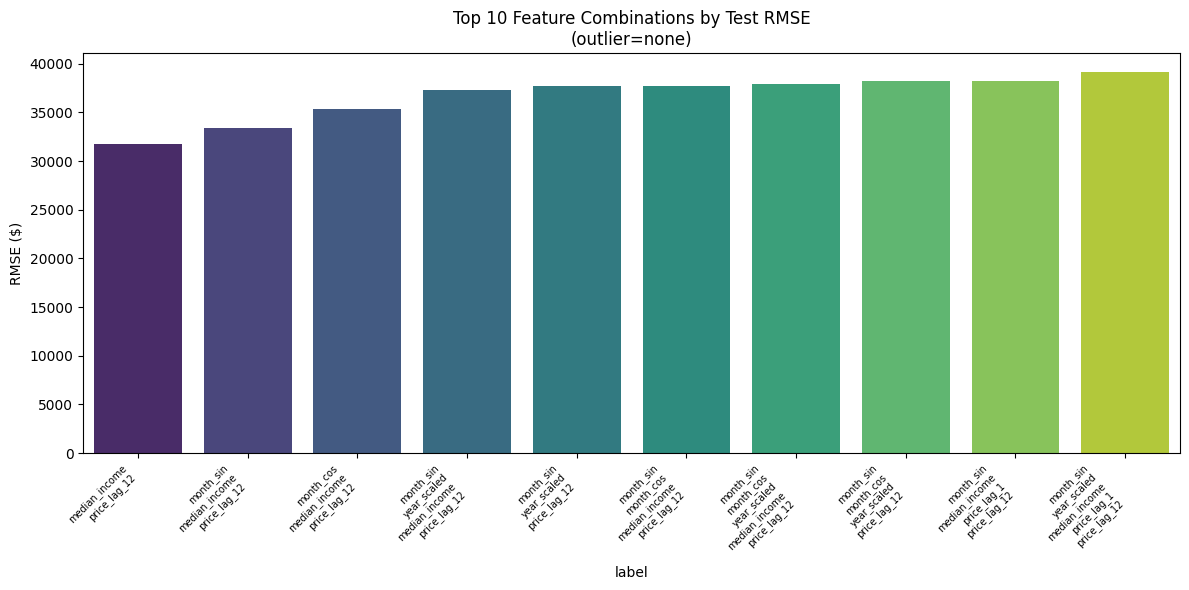

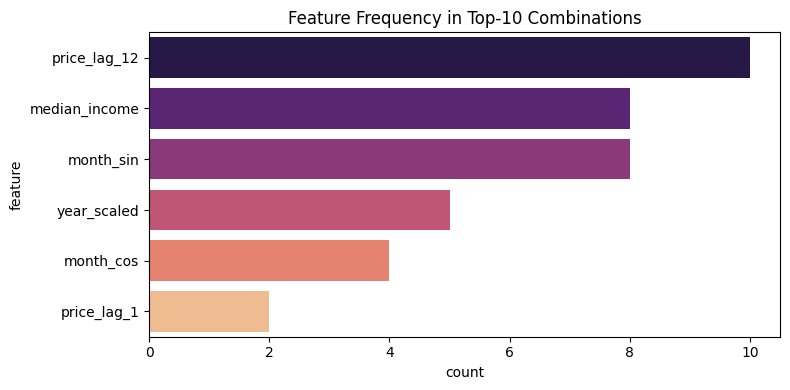

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from itertools import combinations

# ============================================================
# All possible feature combinations
# ============================================================

ALL_FEATURES = [
    "month_sin",
    "month_cos",
    "year_scaled",
    "avg_bedrooms",
    "house_ratio",
    "sales_count",
    "mortgage_rate",
    "median_income",
    "price_lag_1",
    "price_lag_12",
]

def calculate_rmse(y_true, y_pred):
    """Root Mean Squared Error in natural price units."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def add_price_lags(df, lags=(1, 12)):
    """
    Create lagged price features.
    These are SAFE because they only use past information.
    """
    df = df.copy()
    for lag in lags:
        df[f"price_lag_{lag}"] = df["price"].shift(lag)
    return df

def get_all_feature_combinations(feature_list, min_features=1):
    """Generate all non-empty subsets of features."""
    combos = []
    for r in range(min_features, len(feature_list) + 1):
        for combo in combinations(feature_list, r):
            combos.append(list(combo))
    return combos #returns a list of lists, where each inner list is a combination of features to try in the Random Forest model.


def rf_feature_search(
    df,
    pipeline_function,
    add_seasonality_function,
    outlier_method="none",
    train_size=0.8,
    lag_values=(1, 12),
    rf_params=None,
    min_features=1,
    top_n=10,
):
    """
    Fit a Random Forest for EVERY combination of features and rank by test RMSE.

    Parameters
    ----------
    top_n : int
        How many best combinations to print/plot at the end.
    """

    if rf_params is None:
        rf_params = {"n_estimators": 100, "max_depth": 10, "random_state": 42, "n_jobs": -1}

    # ── 1. Prepare data once ───────────────────────────────────────────────────
    df_cleaned, monthly, monthly_df = pipeline_function(
        df, type_of_outlier=outlier_method, plotting=False
    )
    monthly_df = add_seasonality_function(monthly_df)
    monthly_df = add_price_lags(monthly_df, lag_values)
    monthly_df = monthly_df.dropna()

    split_idx = int(len(monthly_df) * train_size)
    train = monthly_df.iloc[:split_idx]
    test  = monthly_df.iloc[split_idx:]
    y_train = train["price"]
    y_test  = test["price"]

    # ── 2. Generate all feature combos ────────────────────────────────────────
    # Only keep combos whose columns actually exist in monthly_df
    available = [f for f in ALL_FEATURES if f in monthly_df.columns]
    all_combos = get_all_feature_combinations(available, min_features=min_features)
    print(f"Total combinations to evaluate: {len(all_combos)}")

    # ── 3. Evaluate every combo ───────────────────────────────────────────────
    records = []

    for feature_cols in all_combos:
        print(f'Combination number {all_combos.index(feature_cols) + 1} of {len(all_combos)}')
        print(f"Evaluating features: {feature_cols} ...")
        X_train = train[feature_cols]

        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            index=X_train.index,
            columns=X_train.columns,
        )

        model = RandomForestRegressor(**rf_params)
        model.fit(X_train_scaled, y_train)

        # Recursive prediction if lags are in the feature set
        lagged_cols = [f for f in feature_cols if f.startswith("price_lag_")]
        exog_cols   = [f for f in feature_cols if not f.startswith("price_lag_")]

        if lagged_cols:
            history = list(y_train.values)
            max_lag = max(int(f.split("_")[-1]) for f in lagged_cols)
            if len(history) < max_lag:
                history = [history[0]] * (max_lag - len(history)) + history

            preds = []
            for i in range(len(test)):
                row = {f: test.iloc[i][f] for f in exog_cols}
                for lag_col in lagged_cols:
                    lag = int(lag_col.split("_")[-1])
                    row[lag_col] = history[-lag]

                X_row = pd.DataFrame([row], columns=feature_cols)
                pred  = model.predict(scaler.transform(X_row))[0]
                preds.append(pred)
                history.append(pred)
            preds = np.array(preds)
        else:
            X_test_scaled = scaler.transform(test[feature_cols])
            preds = model.predict(X_test_scaled)

        # Inverse log if needed
        if outlier_method == "log_transform":
            actual = np.exp(y_test.values)
            preds  = np.exp(preds)
        else:
            actual = y_test.values

        rmse = np.sqrt(mean_squared_error(actual, preds))
        records.append({"features": tuple(feature_cols), "n_features": len(feature_cols), "rmse": rmse})

    # ── 4. Rank results ───────────────────────────────────────────────────────
    results_df = (
        pd.DataFrame(records)
        .sort_values("rmse")
        .reset_index(drop=True)
    )

    print(f"\nTop {top_n} feature combinations (lowest RMSE):")
    print(results_df.head(top_n).to_string())

    # ── 5. Plot top-N ─────────────────────────────────────────────────────────
    top = results_df.head(top_n).copy()
    top["label"] = top["features"].apply(lambda x: "\n".join(x))

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top, x="label", y="rmse", palette="viridis")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.title(f"Top {top_n} Feature Combinations by Test RMSE\n(outlier={outlier_method})")
    plt.ylabel("RMSE ($)")
    plt.tight_layout()
    plt.savefig(f"./imgs/rf_feature_search_{outlier_method}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 6. Feature frequency in top-N ─────────────────────────────────────────
    from collections import Counter
    freq = Counter(f for combo in results_df.head(top_n)["features"] for f in combo)
    freq_df = pd.DataFrame(freq.items(), columns=["feature", "count"]).sort_values("count", ascending=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=freq_df, x="count", y="feature", palette="magma")
    plt.title(f"Feature Frequency in Top-{top_n} Combinations")
    plt.tight_layout()
    plt.savefig(f"./imgs/rf_feature_frequency_{outlier_method}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return results_df


# ── Run ───────────────────────────────────────────────────────────────────────
results = rf_feature_search(
    df=df,
    pipeline_function=pipeline,
    add_seasonality_function=add_seasonality_features,
    outlier_method="none",
    train_size=train_size,
    lag_values=(1, 12),
    rf_params={"n_estimators": 100, "max_depth": 10, "random_state": 42, "n_jobs": -1},
    top_n=10,
)


Top 50 feature combinations (lowest RMSE):
                                                                                                     features  n_features          rmse
0                                                                               (median_income, price_lag_12)           2  31749.199385
1                                                                    (month_sin, median_income, price_lag_12)           3  33409.974592
2                                                                    (month_cos, median_income, price_lag_12)           3  35325.605002
3                                                       (month_sin, year_scaled, median_income, price_lag_12)           4  37317.204001
4                                                                      (month_sin, year_scaled, price_lag_12)           3  37683.709043
5                                                         (month_sin, month_cos, median_income, price_lag_12)           4  37759.500412
6   

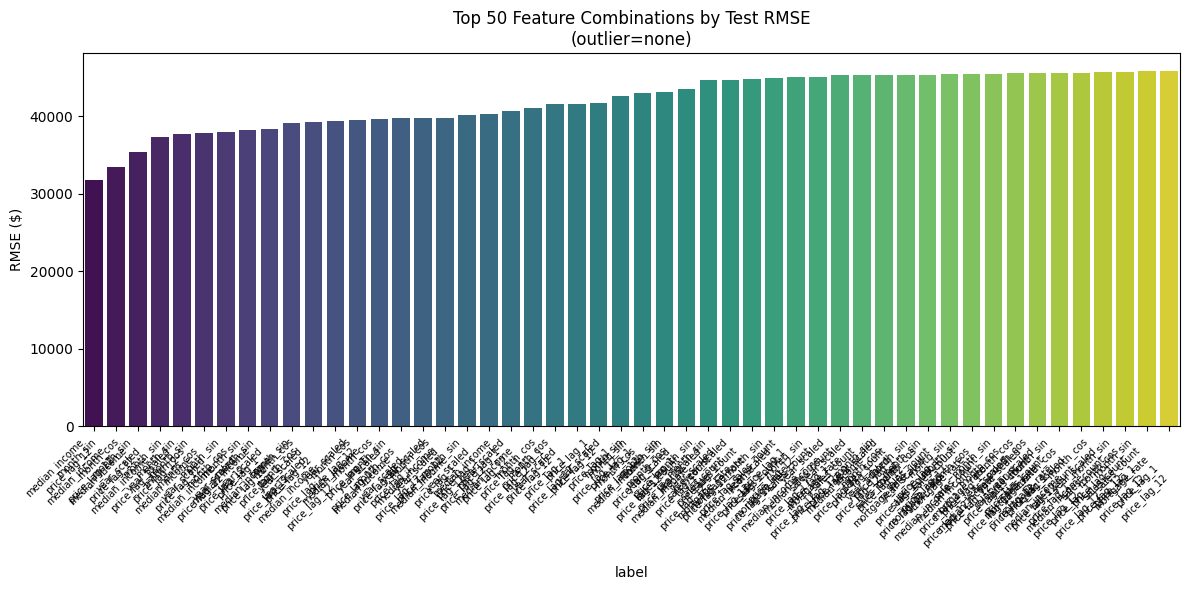

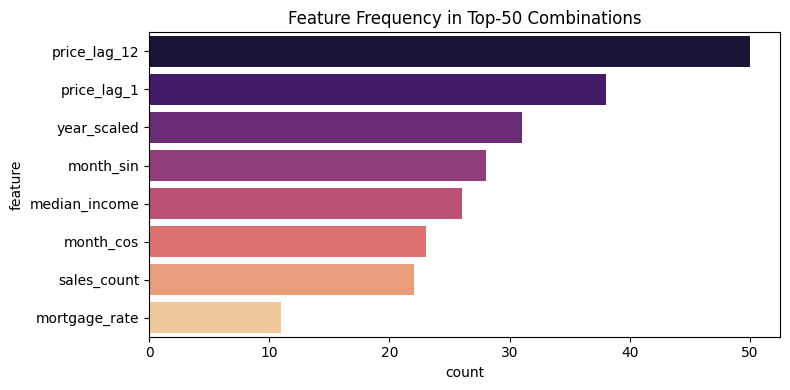

In [ ]:
top_n = 50
outlier_method = "none"

print(f"\nTop {top_n} feature combinations (lowest RMSE):")
print(results.head(top_n).to_string())

# ── 5. Plot top-N ─────────────────────────────────────────────────────────
top = results.head(top_n).copy()
top["label"] = top["features"].apply(lambda x: "\n".join(x))

plt.figure(figsize=(12, 6))
sns.barplot(data=top, x="label", y="rmse", palette="viridis")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.title(f"Top {top_n} Feature Combinations by Test RMSE\n(outlier={outlier_method})")
plt.ylabel("RMSE ($)")
plt.tight_layout()
plt.savefig(f"./imgs/rf_feature_search_{outlier_method}.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6. Feature frequency in top-N ─────────────────────────────────────────
from collections import Counter
freq = Counter(f for combo in results.head(top_n)["features"] for f in combo)
freq_df = pd.DataFrame(freq.items(), columns=["feature", "count"]).sort_values("count", ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=freq_df, x="count", y="feature", palette="magma")
plt.title(f"Feature Frequency in Top-{top_n} Combinations")
plt.tight_layout()
plt.savefig(f"./imgs/rf_feature_frequency_{outlier_method}.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

import shap

# ============================================================
# Feature dictionary (you can change when calling function)
# ============================================================

FEATURE_SETS = {

    "best_features": [
        "median_income",
        "price_lag_12",
        "sales_count"
    ],

    "best_features_no_macro": [
        "month_sin",
        "year_scaled",
        "price_lag_12",
        "sales_count"
    ],

    # Safe long-term forecasting (only calendar, no market variables)
    "known_future": [
        "month_sin",
        "month_cos",
        "year_scaled",
    ],

    # Market features that may be unknown in the future
    "all": [
        "month_sin",
        "month_cos",
        "year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "price_lag_1",
        "price_lag_12",
    ],

    # Everything
    "all_and_macro": [
        "month_sin",
        "month_cos",
        "year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "mortgage_rate",
        "median_income",
        "price_lag_1",
        "price_lag_12",
    ],

    "all_and_macro_no_sales_count": [
        "month_sin",
        "month_cos",
        "year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "median_income",
        "price_lag_12",
    ],
}



# ============================================================
# Utility
# ============================================================

def calculate_rmse(y_true, y_pred):
    """Root Mean Squared Error in natural price units."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def add_price_lags(df, lags=(1, 12)):
    """
    Create lagged price features.
    These are SAFE because they only use past information.
    """
    df = df.copy()
    for lag in lags:
        df[f"price_lag_{lag}"] = df["price"].shift(lag)
    return df

# ============================================================
# MAIN PIPELINE
# ============================================================

def random_forest_evaluation_pipeline(
    df,
    pipeline_function,
    add_seasonality_function,
    train_size=0.8,
    feature_dict=FEATURE_SETS,
    feature_keys=FEATURE_SETS.keys(),
    outlier_methods=("none",),
    use_lags=True,
    lag_values=(1, 12),
    plot=True,
    use_shap=False,
    grid_search=False,
    rf_params=None,
):
    """
    FULLY PARAMETRIC RANDOM FOREST PIPELINE.

    Parameters
    ----------
    df : DataFrame
        Original raw dataset.

    pipeline_function : function
        Your cleaning pipeline(df, type_of_outlier, plotting=False)

    add_seasonality_function : function
        Function that adds sin/cos/month/year features.

    feature_dict : dict
        Dictionary mapping feature-set names to column lists.

    feature_keys : list
        Which feature sets to evaluate.

    use_lags : bool
        If True, adds lagged price features (safe autoregressive).

    grid_search : bool
        If True, runs GridSearchCV to tune RF hyperparameters.

    plot : bool
        Plot forecasts + feature importance.

    use_shap : bool
        Run SHAP explainability (slow).
    """

    # Default RF parameters
    if rf_params is None:
        rf_params = {
            "n_estimators": 300,
            "max_depth": None,
            "random_state": 42,
            "n_jobs": -1,
        }

    # Optional grid search space
    grid_params = {
        "n_estimators": range(100, 501, 100),
        "max_depth": range(5, 16, 5),
        "min_samples_split": [2, 3, 4, 5],
    }

    # ========================================================
    # LOOP over outlier methods and feature sets
    # ========================================================

    for outlier in outlier_methods:
        for key in feature_keys:

            print("\n" + "=" * 60)
            print(f"RF | Outlier: {outlier} | Features: {key}")
            print("=" * 60)

            # --------------------------------------------
            # 1. Run data pipeline
            # --------------------------------------------
            df_cleaned, monthly, monthly_df = pipeline_function(
                df,
                type_of_outlier=outlier,
                plotting=False,
            )

            # Add seasonality features
            monthly_df = add_seasonality_function(monthly_df)

            # Add lagged prices if requested
            if use_lags:
                monthly_df = add_price_lags(monthly_df, lag_values)

            # Drop rows with NaN from lags
            monthly_df = monthly_df.dropna()

            feature_cols = feature_dict[key]

            # --------------------------------------------
            # 2. Train / Test split (time-series safe)
            # --------------------------------------------
            split_idx = int(len(monthly_df) * train_size)

            train = monthly_df.iloc[:split_idx]
            test = monthly_df.iloc[split_idx:]

            X_train = train[feature_cols]
            y_train = train["price"]
            y_test = test["price"]

            # Scale features
            scaler = StandardScaler()
            X_train_scaled = pd.DataFrame(
                scaler.fit_transform(X_train),
                index=X_train.index,
                columns=X_train.columns,
            )

            # --------------------------------------------
            # 3. Train model
            # --------------------------------------------
            model_rf = RandomForestRegressor(**rf_params)
            if grid_search:
                print("Running GridSearchCV...")
                model = GridSearchCV(
                    RandomForestRegressor(random_state=42),
                    grid_params,
                    cv=3,
                    n_jobs=-1,
                )
                model.fit(X_train_scaled, y_train)
                model_rf = model.best_estimator_
                print("Best params:", model.best_params_)
            else:
                model_rf.fit(X_train_scaled, y_train)

            # --------------------------------------------
            # 4. Recursive prediction for lagged features (FIX for data leakage)
            # --------------------------------------------
            # Identify which features are lagged prices
            lagged_price_features = [f for f in feature_cols if f.startswith("price_lag_")]
            exog_features_only = [f for f in feature_cols if not f.startswith("price_lag_")]

            preds = []

            if lagged_price_features:
                # Initialize history for lags with training actuals
                history_for_lags = list(y_train.values)

                # Ensure history_for_lags is sufficiently long to cover the largest lag needed
                max_lag_val = max([int(f.split('_')[-1]) for f in lagged_price_features])
                if len(history_for_lags) < max_lag_val:
                    padding_needed = max_lag_val - len(history_for_lags)
                    history_for_lags = [history_for_lags[-1]] * padding_needed + history_for_lags

                # For each step in the test set, make a recursive prediction
                for i in range(len(test)):
                    current_features_dict = {}

                    # Populate exogenous features from the test set
                    for f in exog_features_only:
                        current_features_dict[f] = test.iloc[i][f]

                    # Populate lagged price features using the recursive history
                    for lag_col_name in lagged_price_features:
                        lag_value = int(lag_col_name.split('_')[-1])
                        current_features_dict[lag_col_name] = history_for_lags[-lag_value]

                    # Convert to DataFrame, ensuring correct column order for prediction
                    X_input_for_pred = pd.DataFrame([current_features_dict], columns=X_train.columns)
                    X_input_for_pred_scaled = scaler.transform(X_input_for_pred)

                    # Predict the current step
                    current_pred = model_rf.predict(X_input_for_pred_scaled)[0]
                    preds.append(current_pred)

                    # Update history_for_lags with the new prediction for the next iteration
                    history_for_lags.append(current_pred)
            else:
                # If no lags, direct prediction is fine.
                X_test_direct = test[feature_cols]
                X_test_direct_scaled = scaler.transform(X_test_direct)
                preds = model_rf.predict(X_test_direct_scaled)

            # Convert to numpy array for consistency with other parts of the pipeline
            preds = np.array(preds)

            # --------------------------------------------
            # 5. Inverse transform if log prices
            # --------------------------------------------
            if outlier == "log_transform":
                actual = np.exp(y_test.values)
                preds = np.exp(preds)
                history = np.exp(monthly_df["price"].values)
            else:
                actual = y_test.values
                history = monthly_df["price"].values

            # --------------------------------------------
            # 6. RMSE
            # --------------------------------------------
            rmse = calculate_rmse(actual, preds)
            print(f"RMSE = ${rmse:,.2f}")

            # --------------------------------------------
            # 7. Plot forecast
            # --------------------------------------------
            if plot:
                plt.figure(figsize=(12, 6))
                plt.plot(monthly_df.index, history, color="lightgray", label="History")
                plt.plot(test.index, actual, color="black", label="Actual")
                plt.plot(test.index, preds, "--", label=f"RF (RMSE={int(rmse):,})")
                plt.title(f"RF Forecast | {key} | {outlier}")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.savefig(f'./imgs/rf2_forecast_{outlier}_{key}.png', dpi=150, bbox_inches='tight')
                plt.show()

                # Feature importance
                importance = pd.Series(
                    model_rf.feature_importances_,
                    index=feature_cols,
                ).sort_values(ascending=False)

                print("\nFeature Importance:")
                print(importance.round(4))

                plt.figure(figsize=(8, 4))
                sns.barplot(x=importance.values, y=importance.index)
                plt.title("Feature Importance")
                plt.savefig(f'./imgs/rf2_importance_{outlier}_{key}.png', dpi=150, bbox_inches='tight')
                plt.show()

            # --------------------------------------------
            # 8. SHAP (optional, slow)
            # --------------------------------------------
            if use_shap:
                explainer = shap.TreeExplainer(model_rf)
                # SHAP for recursive models is complex.
                # For simplicity, we'll run SHAP on the X_test constructed *without* recursion for interpretability.
                X_test_for_shap = test[feature_cols]
                X_test_for_shap_scaled = pd.DataFrame(
                    scaler.transform(X_test_for_shap),
                    index=X_test_for_shap.index,
                    columns=X_test_for_shap.columns,
                )
                shap_values = explainer.shap_values(X_test_for_shap_scaled)

                #the way shap works (explainer.shap_values) is that it returns a matrix of SHAP values for each feature and each sample in the test set.
                #then, shap.summary_plot takes these SHAP values and creates a summary plot that shows the impact of each feature on the model's predictions across all samples.

                shap.summary_plot(shap_values, X_test_for_shap_scaled, show=False)
                plt.savefig(f'./imgs/rf2_shap_{outlier}_{key}.png', dpi=150, bbox_inches='tight')
                plt.show()

In [52]:
# ============================================================
# Feature dictionary (you can change when calling function)
# ============================================================

FEATURE_SETS = {

    "best_features": [
        "median_income",
        "price_lag_12",
    ],

    "best_features_no_macro": [
        "month_sin",
        "year_scaled",
        "price_lag_12",
    ],

    # Safe long-term forecasting (only calendar, no market variables)
    "known_future": [
        "month_sin",
        "month_cos",
        "year_scaled",
    ],

    # Market features that may be unknown in the future
    "all": [
        "month_sin",
        "month_cos",
        "year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "price_lag_1",
        "price_lag_12",
    ],

    # Everything
    "all_and_macro": [
        "month_sin",
        "month_cos",
        "year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "mortgage_rate",
        "median_income",
        "price_lag_1",
        "price_lag_12",
    ],

    "all_and_macro_no_sales_count": [
        "month_sin",
        "month_cos",
        "year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "median_income",
        "price_lag_12",
    ],
}

In [43]:
FEATURE_SETS = {
    "top_1":  ["median_income", "price_lag_12"],
    "top_2":  ["month_sin", "median_income", "price_lag_12"],
    "top_3":  ["month_cos", "median_income", "price_lag_12"],
    "top_4":  ["month_sin", "year_scaled", "median_income", "price_lag_12"],
    "top_5":  ["month_sin", "year_scaled", "price_lag_12"],
    "features":  ["month_sin", "month_cos", "median_income", "price_lag_12", "mortgage_rate"],
    "top_7":  ["month_sin", "month_cos", "year_scaled", "median_income", "price_lag_12"],
    "top_8":  ["month_sin", "month_cos", "year_scaled", "price_lag_12"],
    "top_9":  ["month_sin", "median_income", "price_lag_1", "price_lag_12"],
    "top_10": ["month_sin", "year_scaled", "median_income", "price_lag_1", "price_lag_12"],
    "top_11": ["month_cos", "year_scaled", "price_lag_12"],
    "top_12": ["month_sin", "month_cos", "year_scaled", "median_income", "price_lag_1", "price_lag_12"],
    "top_13": ["year_scaled", "price_lag_12"],
}


RF | Outlier: none | Features: features
Running GridSearchCV...
Best params: {'max_depth': 10, 'min_samples_split': 4, 'n_estimators': 500}
RMSE = $35,674.57


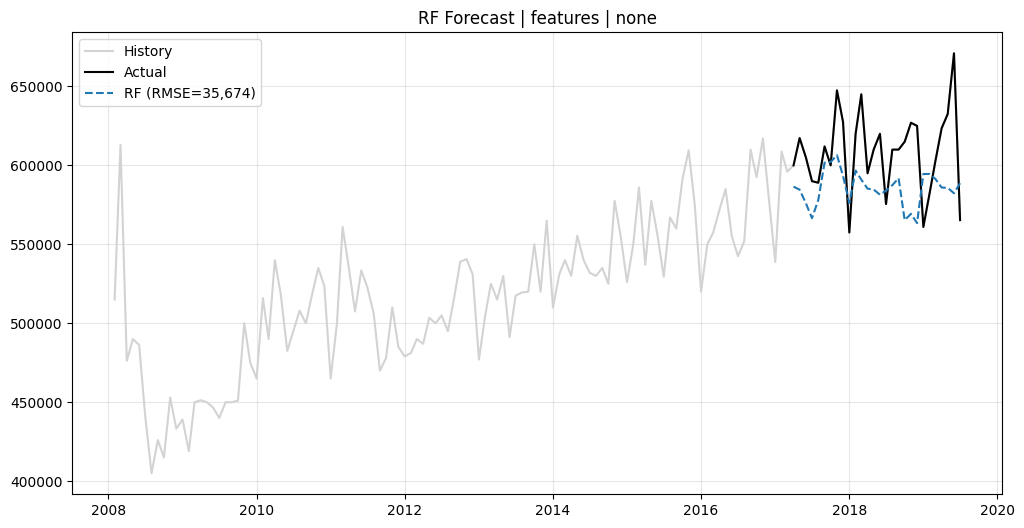


Feature Importance:
mortgage_rate    0.3825
median_income    0.3190
price_lag_12     0.2270
month_sin        0.0443
month_cos        0.0272
dtype: float64


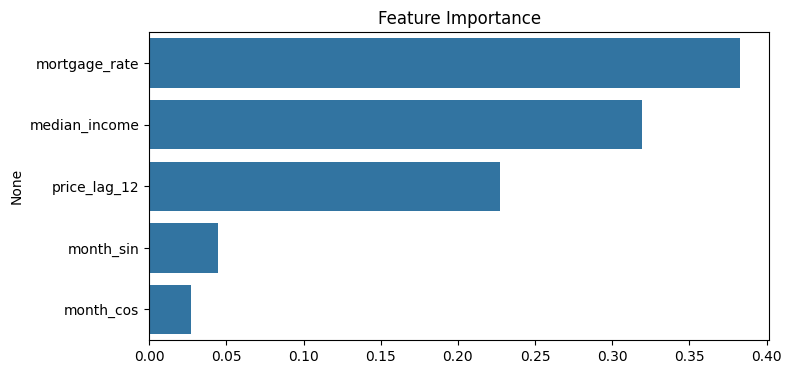

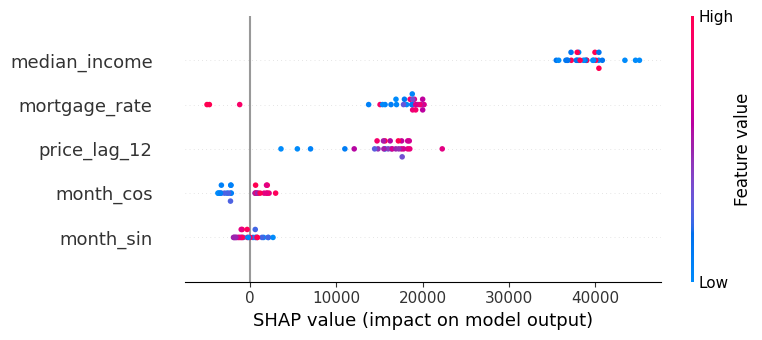

In [44]:
random_forest_evaluation_pipeline(
    df=df,
    pipeline_function=pipeline,
    add_seasonality_function=add_seasonality_features,
    feature_dict=FEATURE_SETS,
    feature_keys=['features'],  # FEATURE_SETS.keys(),
    outlier_methods=("none",),  # "remove"),

    use_lags=True,
    lag_values=(1, 12),

    plot=True,
    use_shap=True,
    grid_search=True,
)

In [51]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge # Added Linear Model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

#import shap

# ============================================================
# Feature dictionary (you can change when calling function)
# ============================================================

FEATURE_SETS = {
    "best_features": [
        "median_income",
        "price_lag_12",
    ],
    "best_features_no_macro": [
        "month_sin",
        "year_scaled",
        "price_lag_12",
    ],
    "known_future": [
        "month_sin",
        "month_cos",
        "year_scaled",
    ],
    "all_except_sales": [
        "year_scaled",
        "month_sin",
        "month_cos",
        "avg_bedrooms",
        "house_ratio",
        "mortgage_rate",
        "median_income",
        "price_lag_1",
        "price_lag_12",
    ],
}

# ============================================================
# Utility
# ============================================================

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def add_price_lags(df, lags=(1, 12)):
    df = df.copy()
    for lag in lags:
        df[f"price_lag_{lag}"] = df["price"].shift(lag)
    return df

# ============================================================
# MAIN PIPELINE
# ============================================================

def random_forest_evaluation_pipeline_LR(
    df,
    pipeline_function,
    add_seasonality_function,
    train_size=0.8,
    feature_dict=FEATURE_SETS,
    feature_keys=FEATURE_SETS.keys(),
    outlier_methods=("none",),
    use_lags=True,
    lag_values=(1, 12),
    plot=True,
    use_shap=False,
    grid_search=False,
    rf_params=None,
):

    if rf_params is None:
        rf_params = {
            "n_estimators": 300,
            "max_depth": None,
            "random_state": 42,
            "n_jobs": -1,
        }

    grid_params = {
        "n_estimators": range(100, 501, 100),
        "max_depth": range(5, 16, 5),
        "min_samples_split": [2, 3, 4, 5],
    }

    for outlier in outlier_methods:
        for key in feature_keys:

            print("\n" + "=" * 60)
            print(f"Hybrid Linear+RF | Outlier: {outlier} | Features: {key}")
            print("=" * 60)

            # 1. Run data pipeline
            df_cleaned, monthly, monthly_df = pipeline_function(
                df,
                type_of_outlier=outlier,
                plotting=False,
            )

            monthly_df = add_seasonality_function(monthly_df)

            if use_lags:
                monthly_df = add_price_lags(monthly_df, lag_values)

            monthly_df = monthly_df.dropna()
            feature_cols = feature_dict[key]

            # 2. Train / Test split
            split_idx = int(len(monthly_df) * train_size)

            train = monthly_df.iloc[:split_idx]
            test = monthly_df.iloc[split_idx:]

            X_train = train[feature_cols]
            y_train = train["price"]
            y_test = test["price"]

            scaler = StandardScaler()
            X_train_scaled = pd.DataFrame(
                scaler.fit_transform(X_train),
                index=X_train.index,
                columns=X_train.columns,
            )

            # --------------------------------------------
            # 3. Train Hybrid Model (Linear Trend + RF Residuals)
            # --------------------------------------------
            
            # Step A: Fit Linear Model
            model_linear = Ridge(alpha=1.0)
            model_linear.fit(X_train_scaled, y_train)
            
            # Step B: Calculate Residuals
            y_train_pred_linear = model_linear.predict(X_train_scaled)
            y_train_residuals = y_train - y_train_pred_linear

            # Step C: Fit RF on the Residuals
            model_rf = RandomForestRegressor(**rf_params)
            
            if grid_search:
                print("Running GridSearchCV on residuals...")
                model = GridSearchCV(
                    RandomForestRegressor(random_state=42),
                    grid_params,
                    cv=3,
                    n_jobs=-1,
                )
                # Fit on residuals instead of actual y_train
                model.fit(X_train_scaled, y_train_residuals) 
                model_rf = model.best_estimator_
                print("Best params:", model.best_params_)
            else:
                # Fit on residuals instead of actual y_train
                model_rf.fit(X_train_scaled, y_train_residuals)

            # --------------------------------------------
            # 4. Recursive prediction 
            # --------------------------------------------
            lagged_price_features = [f for f in feature_cols if f.startswith("price_lag_")]
            exog_features_only = [f for f in feature_cols if not f.startswith("price_lag_")]

            preds = []

            if lagged_price_features:
                history_for_lags = list(y_train.values)

                max_lag_val = max([int(f.split('_')[-1]) for f in lagged_price_features])
                if len(history_for_lags) < max_lag_val:
                    padding_needed = max_lag_val - len(history_for_lags)
                    history_for_lags = [history_for_lags[-1]] * padding_needed + history_for_lags

                for i in range(len(test)):
                    current_features_dict = {}

                    for f in exog_features_only:
                        current_features_dict[f] = test.iloc[i][f]

                    for lag_col_name in lagged_price_features:
                        lag_value = int(lag_col_name.split('_')[-1])
                        current_features_dict[lag_col_name] = history_for_lags[-lag_value]

                    X_input_for_pred = pd.DataFrame([current_features_dict], columns=X_train.columns)
                    X_input_for_pred_scaled = scaler.transform(X_input_for_pred)

                    # Predict trend component
                    pred_linear = model_linear.predict(X_input_for_pred_scaled)[0]
                    
                    # Predict residual component
                    pred_residual = model_rf.predict(X_input_for_pred_scaled)[0]
                    
                    # Combine for final prediction
                    current_pred = pred_linear + pred_residual
                    preds.append(current_pred)

                    history_for_lags.append(current_pred)
            else:
                X_test_direct = test[feature_cols]
                X_test_direct_scaled = scaler.transform(X_test_direct)
                
                # Predict both components and sum them
                preds_linear = model_linear.predict(X_test_direct_scaled)
                preds_residual = model_rf.predict(X_test_direct_scaled)
                preds = preds_linear + preds_residual

            preds = np.array(preds)

            # 5. Inverse transform
            if outlier == "log_transform":
                actual = np.exp(y_test.values)
                preds = np.exp(preds)
                history = np.exp(monthly_df["price"].values)
            else:
                actual = y_test.values
                history = monthly_df["price"].values

            # 6. RMSE
            rmse = calculate_rmse(actual, preds)
            print(f"RMSE = ${rmse:,.2f}")

            # 7. Plot forecast
            if plot:
                plt.figure(figsize=(12, 6))
                plt.plot(monthly_df.index, history, color="lightgray", label="History")
                plt.plot(test.index, actual, color="black", label="Actual")
                plt.plot(test.index, preds, "--", label=f"Hybrid (RMSE={int(rmse):,})")
                plt.title(f"Hybrid Forecast | {key} | {outlier}")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.savefig(f'./imgs/hybrid_forecast_{outlier}_{key}.png', dpi=150, bbox_inches='tight')
                plt.show()

                importance = pd.Series(
                    model_rf.feature_importances_,
                    index=feature_cols,
                ).sort_values(ascending=False)

                print("\nRF Residual Feature Importance:")
                print(importance.round(4))

                plt.figure(figsize=(8, 4))
                sns.barplot(x=importance.values, y=importance.index)
                plt.title("RF Residual Feature Importance")
                plt.savefig(f'./imgs/hybrid_importance_{outlier}_{key}.png', dpi=150, bbox_inches='tight')
                plt.show()

                linear_coefs = pd.Series(
                    model_linear.coef_,
                    index=feature_cols,
                ).sort_values(ascending=False)

                print("\nLinear Model Coefficients (Global Trend):")
                print(linear_coefs.round(4))

                plt.figure(figsize=(8, 4))
                # Using a diverging palette to clearly show positive vs negative impact
                sns.barplot(x=linear_coefs.values, y=linear_coefs.index, palette="vlag")
                plt.title("Linear Model Coefficients (Trend & Seasonality Base)")
                plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Add a vertical zero line
                plt.grid(True, axis='x', alpha=0.3)
                plt.tight_layout()
                plt.savefig(f'./imgs/hybrid_linear_coefs_{outlier}_{key}.png', dpi=150, bbox_inches='tight')
                plt.show()

            # 8. SHAP
            if use_shap:
                explainer = shap.TreeExplainer(model_rf)
                X_test_for_shap = test[feature_cols]
                X_test_for_shap_scaled = pd.DataFrame(
                    scaler.transform(X_test_for_shap),
                    index=X_test_for_shap.index,
                    columns=X_test_for_shap.columns,
                )
                shap_values = explainer.shap_values(X_test_for_shap_scaled)

                # NOTE: This explains the predictions of the residuals, not the overall price.
                shap.summary_plot(shap_values, X_test_for_shap_scaled, show=False)
                plt.title("SHAP Values (Predicting Residuals)")
                plt.savefig(f'./imgs/hybrid_shap_{outlier}_{key}.png', dpi=150, bbox_inches='tight')
                plt.show()

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from itertools import combinations

ALL_FEATURES = [
    "month_sin",
    "month_cos",
    "year_scaled",
    "avg_bedrooms",
    "house_ratio",
    "sales_count",
    "mortgage_rate",
    "median_income",
    "price_lag_1",
    "price_lag_12",
]

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def add_price_lags(df, lags=(1, 12)):
    df = df.copy()
    for lag in lags:
        df[f"price_lag_{lag}"] = df["price"].shift(lag)
    return df

def get_all_feature_combinations(feature_list, min_features=1):
    combos = []
    for r in range(min_features, len(feature_list) + 1):
        for combo in combinations(feature_list, r):
            combos.append(list(combo))
    return combos


def hybrid_lr_feature_search(
    df,
    pipeline_function,
    add_seasonality_function,
    outlier_method="none",
    train_size=0.8,
    lag_values=(1, 12),
    rf_params=None,
    ridge_alpha=1.0,
    min_features=1,
    top_n=10,
):
    """
    Fit a Hybrid Ridge+RF model for EVERY combination of features
    and rank by test RMSE. Compatible with random_forest_evaluation_pipeline_LR.

    Parameters
    ----------
    ridge_alpha : float
        Regularisation strength for the Ridge linear model.
    top_n : int
        How many best combinations to print/plot at the end.
    """

    if rf_params is None:
        rf_params = {"n_estimators": 100, "max_depth": 10, "random_state": 42, "n_jobs": -1}

    # ── 1. Prepare data once ───────────────────────────────────────────────────
    df_cleaned, monthly, monthly_df = pipeline_function(
        df, type_of_outlier=outlier_method, plotting=False
    )
    monthly_df = add_seasonality_function(monthly_df)
    monthly_df = add_price_lags(monthly_df, lag_values)
    monthly_df = monthly_df.dropna()

    split_idx = int(len(monthly_df) * train_size)
    train = monthly_df.iloc[:split_idx]
    test  = monthly_df.iloc[split_idx:]
    y_train = train["price"]
    y_test  = test["price"]

    # ── 2. Generate all feature combos ────────────────────────────────────────
    available = [f for f in ALL_FEATURES if f in monthly_df.columns]
    all_combos = get_all_feature_combinations(available, min_features=min_features)
    print(f"Total combinations to evaluate: {len(all_combos)}")

    # ── 3. Evaluate every combo ───────────────────────────────────────────────
    records = []

    for idx, feature_cols in enumerate(all_combos):
        print(f"Combination {idx + 1}/{len(all_combos)}: {feature_cols}")

        X_train = train[feature_cols]

        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            index=X_train.index,
            columns=X_train.columns,
        )

        # ── Step A: Fit Ridge (linear trend) ──────────────────────────────────
        model_linear = Ridge(alpha=ridge_alpha)
        model_linear.fit(X_train_scaled, y_train)

        # ── Step B: Compute residuals ──────────────────────────────────────────
        y_train_pred_linear = model_linear.predict(X_train_scaled)
        y_train_residuals   = y_train - y_train_pred_linear

        # ── Step C: Fit RF on residuals ────────────────────────────────────────
        model_rf = RandomForestRegressor(**rf_params)
        model_rf.fit(X_train_scaled, y_train_residuals)

        # ── Step D: Recursive prediction ──────────────────────────────────────
        lagged_cols = [f for f in feature_cols if f.startswith("price_lag_")]
        exog_cols   = [f for f in feature_cols if not f.startswith("price_lag_")]

        preds = []

        if lagged_cols:
            history = list(y_train.values)
            max_lag = max(int(f.split("_")[-1]) for f in lagged_cols)
            if len(history) < max_lag:
                history = [history[0]] * (max_lag - len(history)) + history

            for i in range(len(test)):
                row = {f: test.iloc[i][f] for f in exog_cols}
                for lag_col in lagged_cols:
                    lag = int(lag_col.split("_")[-1])
                    row[lag_col] = history[-lag]

                X_row        = pd.DataFrame([row], columns=feature_cols)
                X_row_scaled = scaler.transform(X_row)

                pred_linear   = model_linear.predict(X_row_scaled)[0]
                pred_residual = model_rf.predict(X_row_scaled)[0]
                pred          = pred_linear + pred_residual

                preds.append(pred)
                history.append(pred)

            preds = np.array(preds)
        else:
            X_test_scaled = scaler.transform(test[feature_cols])
            preds = model_linear.predict(X_test_scaled) + model_rf.predict(X_test_scaled)

        # ── Inverse log if needed ──────────────────────────────────────────────
        if outlier_method == "log_transform":
            actual = np.exp(y_test.values)
            preds  = np.exp(preds)
        else:
            actual = y_test.values

        rmse = calculate_rmse(actual, preds)
        records.append({
            "features":   tuple(feature_cols),
            "n_features": len(feature_cols),
            "rmse":       rmse,
        })

    # ── 4. Rank results ───────────────────────────────────────────────────────
    results_df = (
        pd.DataFrame(records)
        .sort_values("rmse")
        .reset_index(drop=True)
    )

    print(f"\nTop {top_n} feature combinations (lowest RMSE):")
    print(results_df.head(top_n).to_string())

    # ── 5. Plot top-N ─────────────────────────────────────────────────────────
    top = results_df.head(top_n).copy()
    top["label"] = top["features"].apply(lambda x: "\n".join(x))

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top, x="label", y="rmse", palette="viridis")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.title(f"Top {top_n} Hybrid Feature Combinations by Test RMSE\n(outlier={outlier_method})")
    plt.ylabel("RMSE ($)")
    plt.tight_layout()
    plt.savefig(f"./imgs/hybrid_feature_search_{outlier_method}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── 6. Feature frequency in top-N ─────────────────────────────────────────
    from collections import Counter
    freq    = Counter(f for combo in results_df.head(top_n)["features"] for f in combo)
    freq_df = pd.DataFrame(freq.items(), columns=["feature", "count"]).sort_values("count", ascending=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=freq_df, x="count", y="feature", palette="magma")
    plt.title(f"Feature Frequency in Top-{top_n} Hybrid Combinations")
    plt.tight_layout()
    plt.savefig(f"./imgs/hybrid_feature_frequency_{outlier_method}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return results_df

Total combinations to evaluate: 1013
Combination 1/1013: ['month_sin', 'month_cos']
Combination 2/1013: ['month_sin', 'year_scaled']
Combination 3/1013: ['month_sin', 'avg_bedrooms']
Combination 4/1013: ['month_sin', 'house_ratio']
Combination 5/1013: ['month_sin', 'sales_count']
Combination 6/1013: ['month_sin', 'mortgage_rate']
Combination 7/1013: ['month_sin', 'median_income']
Combination 8/1013: ['month_sin', 'price_lag_1']
Combination 9/1013: ['month_sin', 'price_lag_12']
Combination 10/1013: ['month_cos', 'year_scaled']
Combination 11/1013: ['month_cos', 'avg_bedrooms']
Combination 12/1013: ['month_cos', 'house_ratio']
Combination 13/1013: ['month_cos', 'sales_count']
Combination 14/1013: ['month_cos', 'mortgage_rate']
Combination 15/1013: ['month_cos', 'median_income']
Combination 16/1013: ['month_cos', 'price_lag_1']
Combination 17/1013: ['month_cos', 'price_lag_12']
Combination 18/1013: ['year_scaled', 'avg_bedrooms']
Combination 19/1013: ['year_scaled', 'house_ratio']
Combina

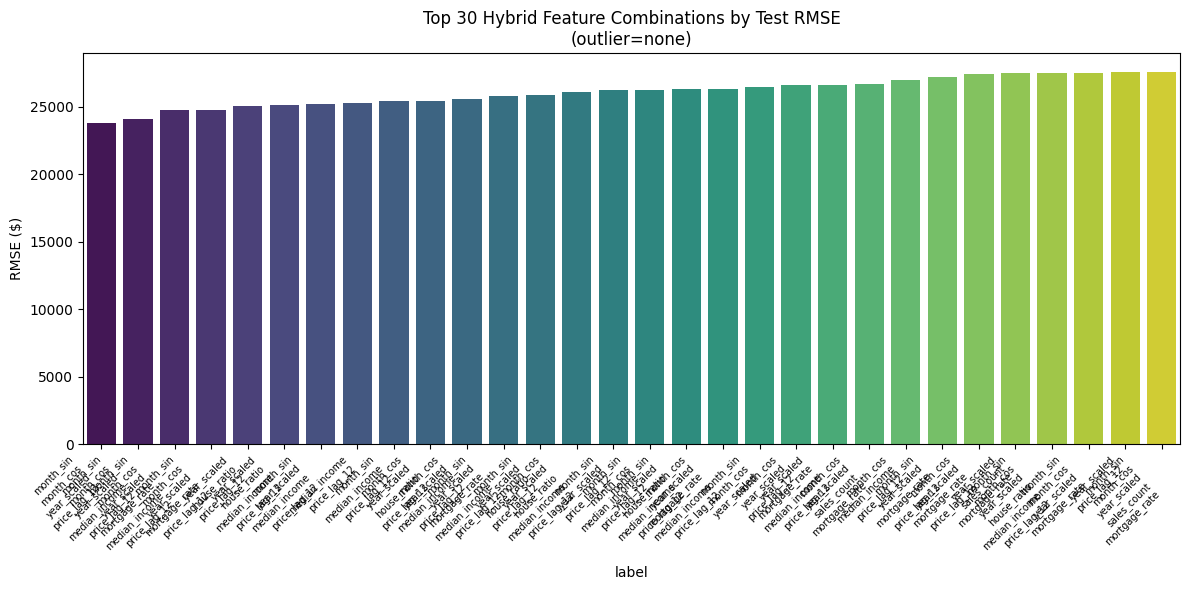

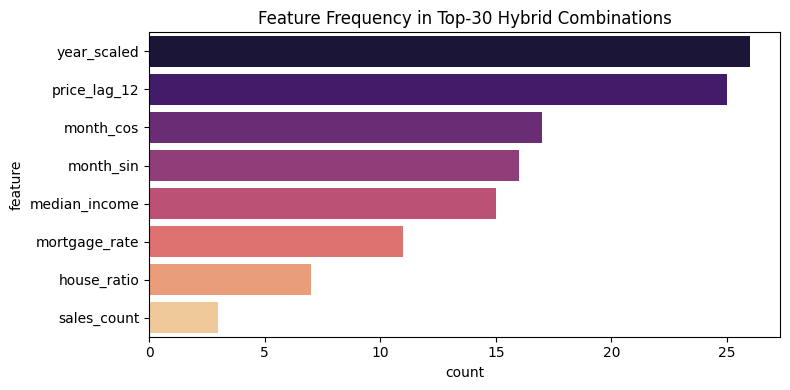

In [42]:
hybrid_results = hybrid_lr_feature_search(
    df=df,
    pipeline_function=pipeline,
    add_seasonality_function=add_seasonality_features,
    outlier_method="none",          # "none" | "remove" | "log_transform"
    train_size=train_size,
    lag_values=(1, 12),
    rf_params={"n_estimators": 100, "max_depth": 10, "random_state": 42, "n_jobs": -1},
    ridge_alpha=1.0,                # Ridge regularisation strength
    min_features=2,                 # minimum features per combo (set >1 to reduce combos)
    top_n=30,
)


Hybrid Linear+RF | Outlier: none | Features: all_no_sales_count
Running GridSearchCV on residuals...
Best params: {'max_depth': 15, 'min_samples_split': 3, 'n_estimators': 400}
RMSE = $25,216.02


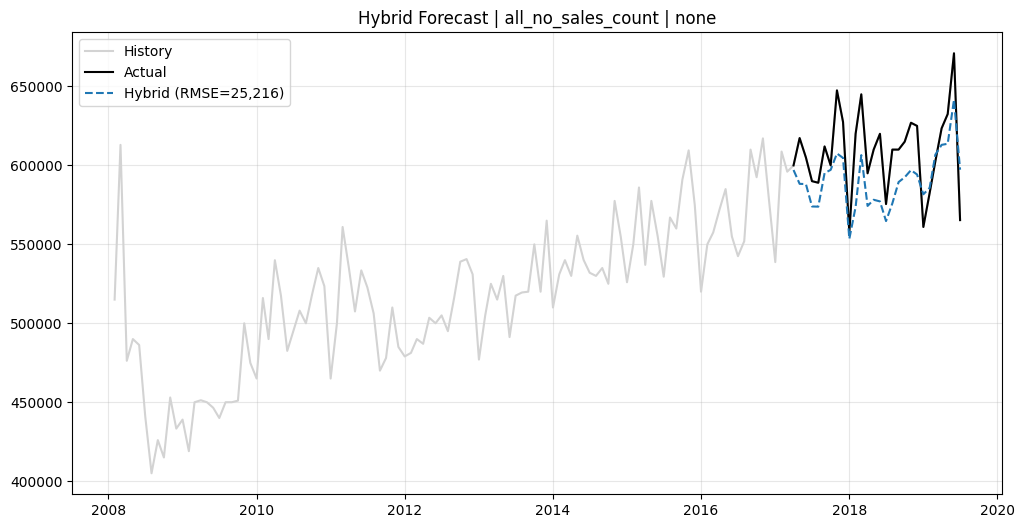


RF Residual Feature Importance:
price_lag_12    0.3956
price_lag_1     0.1589
house_ratio     0.1394
avg_bedrooms    0.0987
month_sin       0.0801
month_cos       0.0673
year_scaled     0.0600
dtype: float64


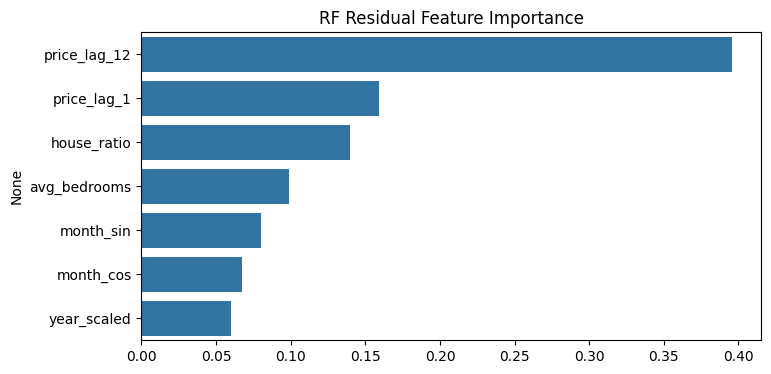


Linear Model Coefficients (Global Trend):
year_scaled     32688.3714
price_lag_1     14881.2882
avg_bedrooms    13581.2177
month_cos        1700.6438
house_ratio      -640.1697
month_sin       -1042.0075
price_lag_12    -8590.4708
dtype: float64


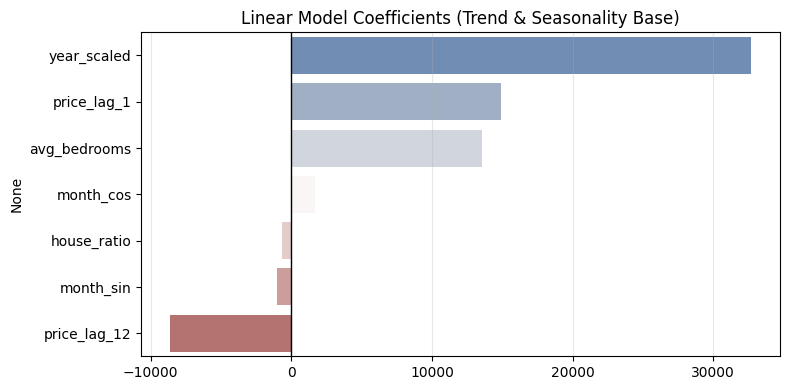

In [53]:
FEATURE_SETS = {
    "best_features": [
        "median_income",
        "price_lag_12",
    ],
    "best_features_no_macro": [
        "month_sin",
        "year_scaled",
        "price_lag_12",
    ],
    "known_future": [
        "month_sin",
        "month_cos",
        "year_scaled",
    ],
    "all_except_sales": [
        "year_scaled",
        "month_sin",
        "month_cos",
        "avg_bedrooms",
        "house_ratio",
        "mortgage_rate",
        "median_income",
        "price_lag_1",
        "price_lag_12",
    ],

    "personalized": [
        "year_scaled",
        "price_lag_12",
        "month_sin",
        "month_cos",
        "median_income"
    ],

    "all_no_sales_count": [
        "year_scaled",
        "month_sin",
        "month_cos",
        "avg_bedrooms",
        "house_ratio",
        #"mortgage_rate",
        #"median_income",
        "price_lag_1",
        "price_lag_12",
    ],
}

random_forest_evaluation_pipeline_LR(
    df=df,
    pipeline_function=pipeline,
    add_seasonality_function=add_seasonality_features,
    feature_dict=FEATURE_SETS,
    feature_keys=['all_no_sales_count'],
    outlier_methods=("none",),  # "remove"),

    use_lags=True,
    lag_values=(1, 12),

    plot=True,
    use_shap=False,
    grid_search=True,
)

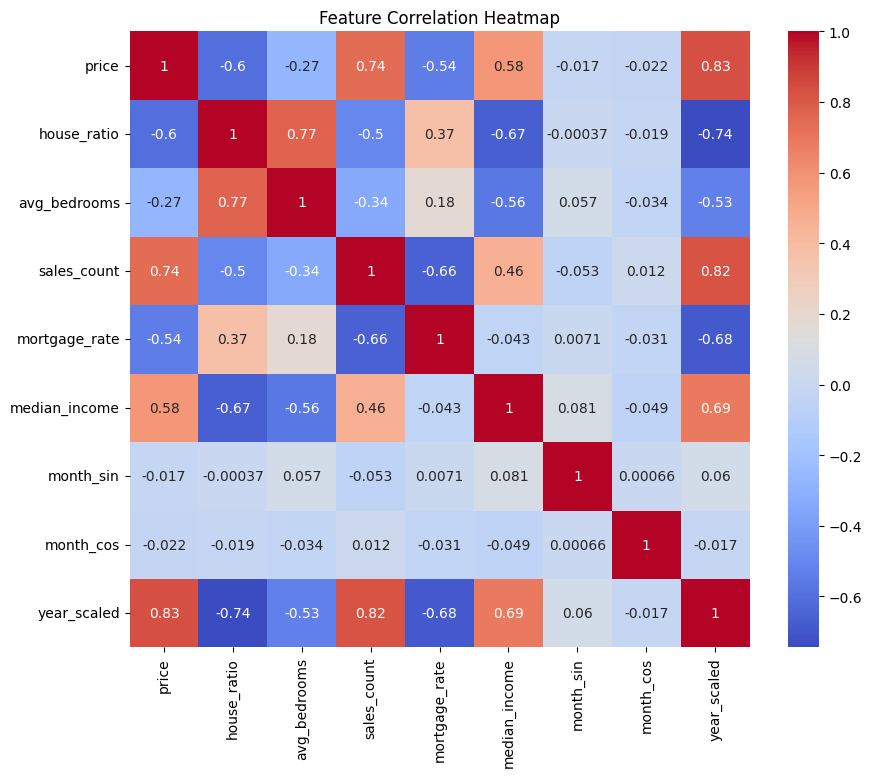

In [65]:
# let's study the redundancy between features. i want to understand if sales count is providing unique information or if it's just a proxy for something else (probably median income and house_ratio)
_, _, monthly_df = pipeline(df, type_of_outlier='remove', plotting=False)
monthly_df = add_seasonality_features(monthly_df)
numeric_cols = [
    'price',
    'house_ratio',
    'avg_bedrooms',
    'sales_count',
    'mortgage_rate',
    'median_income',
    'month_sin',
    'month_cos',
    'year_scaled',
]
plt.figure(figsize=(10, 8))
sns.heatmap(monthly_df[numeric_cols].corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('./imgs/feature_correlation_heatmap_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### LSTM

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
# ── Run LSTM models across outlier strategies ─────────────────────────────────
def create_sequences(X, y, seq_len=12):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)

In [42]:
from itertools import product

def run_lstm_multivariate2(
    monthly_df,
    feature_cols_exog,
    train_size=train_size,
    seq_len=12,
    lstm_units=64,
    dense_units=32,
    epochs=40,
    batch_size=16,
):
    """
    Multivariate AUTOREGRESSIVE LSTM.

    Inputs per timestep:
        [price_lag, exogenous_features]

    IMPORTANT:
    - price history is included as input
    - future true prices are NEVER used
    - scalers fit ONLY on training data
    """

    df = monthly_df.copy()
    target = "price"

    # Include price history as feature 0
    feature_cols = ["price"] + feature_cols_exog

    # -------- Split BEFORE scaling ----------
    split_idx = int(len(df) * train_size)
    train_df = df.iloc[:split_idx]
    test_df  = df.iloc[split_idx:]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    scaler_X.fit(train_df[feature_cols])
    scaler_y.fit(train_df[[target]])

    train_X = scaler_X.transform(train_df[feature_cols])
    test_X  = scaler_X.transform(test_df[feature_cols])

    train_y = scaler_y.transform(train_df[[target]])
    test_y  = scaler_y.transform(test_df[[target]])

    # -------- Build sequences ----------
    def create_sequences(X, y, seq_len):
        Xs, ys = [], []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:i+seq_len])
            ys.append(y[i+seq_len])
        return np.array(Xs), np.array(ys)

    X_train_seq, y_train_seq = create_sequences(train_X, train_y, seq_len)

    # -------- Build model ----------
    model = Sequential([
        LSTM(lstm_units, input_shape=(seq_len, len(feature_cols))),
        Dense(dense_units, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    model.fit(X_train_seq, y_train_seq,
              epochs=epochs,
              batch_size=batch_size,
              verbose=0)

    # -------- Recursive forecasting ----------
    current_seq = train_X[-seq_len:].copy()
    preds_scaled = []

    for i in range(len(test_df)):
        pred = model.predict(
            current_seq.reshape(1, seq_len, len(feature_cols)),
            verbose=0
        )[0,0]

        preds_scaled.append(pred)

        next_row = test_X[i].copy()
        next_row[0] = pred   # replace unknown future price
        current_seq = np.vstack([current_seq[1:], next_row])

    preds = scaler_y.inverse_transform(
        np.array(preds_scaled).reshape(-1,1)
    ).flatten()

    actual = scaler_y.inverse_transform(test_y).flatten()
    rmse = np.sqrt(mean_squared_error(actual, preds))

    return model, preds, actual, rmse

def gridsearch_lstm(
    monthly_df,
    feature_cols,
    param_grid,
    seq_len,
    train_size,
):
    best = None
    results = []

    for params in product(*param_grid.values()):
        cfg = dict(zip(param_grid.keys(), params))

        _, _, _, rmse = run_lstm_multivariate2(
            monthly_df,
            feature_cols_exog=feature_cols,
            train_size=train_size,
            seq_len=seq_len,
            **cfg,
        )

        results.append((cfg, rmse))
        print(cfg, "RMSE:", rmse)

        if best is None or rmse < best[1]:
            best = (cfg, rmse)

    print("\nBest:", best)
    return best, results

param_grid = {
    "lstm_units": [32, 64],
    "dense_units": [16, 32],
    "epochs": [30, 50],
}

In [ ]:
def lstm_evaluation_pipeline2(
    df,
    feature_sets,
    types_of_outlier=("none", "remove", "log_transform"),
    train_size=train_size,
    seq_len=12,
    gridsearch=False,
    param_grid=None,
    plot=True,
    explain=True,
):
    """
    Multivariate autoregressive LSTM evaluation pipeline.

    Parameters
    ----------
    feature_sets : dict
        Example:
            {
              "known": [...],
              "all": [...],
            }

    gridsearch : bool
        Whether to perform hyperparameter search.

    plot : bool
        Plot predictions vs actuals.

    explain : bool
        Run SHAP explanation.
    """

    for type_of_outlier in types_of_outlier:

        # ---------------------------------------------------------
        # Build dataset for this outlier strategy
        # ---------------------------------------------------------
        _, _, monthly_df_cleaned = pipeline(
            df,
            type_of_outlier=type_of_outlier,
            plotting=False
        )

        monthly_df_cleaned = add_seasonality_features(monthly_df_cleaned)

        print(f"\n=== LSTM | outlier method: {type_of_outlier} ===")

        for feat_name, feature_cols_exog in feature_sets.items():

            print(
                f"\n--- LSTM | outlier: {type_of_outlier} "
                f"| features: {feat_name} ---"
            )

            # -----------------------------------------------------
            # Optional Grid Search
            # -----------------------------------------------------
            best_params = {}
            if gridsearch and param_grid is not None:
                best, _ = gridsearch_lstm(
                    monthly_df_cleaned,
                    feature_cols=feature_cols_exog,
                    param_grid=param_grid,
                    seq_len=seq_len,
                    train_size=train_size,
                )
                best_params = best[0]
                print("Best params:", best_params)

            # -----------------------------------------------------
            # Train Model
            # -----------------------------------------------------
            model, preds, actual, rmse = run_lstm_multivariate2(
                monthly_df_cleaned,
                feature_cols_exog=feature_cols_exog,
                train_size=train_size,
                seq_len=seq_len,
                **best_params
            )

            if type_of_outlier == "log_transform":
                actual_dollar = np.exp(actual)
                preds_dollar = np.exp(preds)
                rmse_dollar = calculate_rmse(actual_dollar, preds_dollar)
                history_dollar = np.exp(monthly_df_cleaned["price"].values)
                print(f"Multivariate LSTM RMSE ({feat_name}): ${rmse_dollar:,.2f}")

            else:
                history_dollar = monthly_df_cleaned["price"].values
                actual_dollar = actual
                preds_dollar = preds
                print(f"Multivariate LSTM RMSE ({feat_name}): ${rmse:,.2f}")

            split_idx = int(len(monthly_df_cleaned) * train_size)
            test_dates = monthly_df_cleaned.iloc[split_idx:].index
            full_dates = monthly_df_cleaned.index

            # =====================================================
            # ===================== PLOTTING ======================
            # =====================================================
            if plot:

                plt.figure(figsize=(12, 6))

                plt.plot(
                    full_dates,
                    history_dollar,
                    label="Actual History",
                    color="lightgray",
                    linewidth=2,
                )

                plt.plot(
                    test_dates,
                    actual_dollar,
                    label="Actual Test",
                    color="black",
                    linewidth=2,
                )

                plt.plot(
                    test_dates,
                    preds_dollar,
                    label=f"LSTM ({feat_name}) (RMSE=${int(rmse):,})",
                    linestyle="--",
                    linewidth=2,
                )

                plt.title(
                    f"LSTM Predictions vs Actuals "
                    f"(method: {type_of_outlier}, features: {feat_name})"
                )
                plt.xlabel("Date")
                plt.ylabel("Price ($)")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(f'./imgs/lstm_forecast_{type_of_outlier}_{feat_name}.png', dpi=150, bbox_inches='tight')
                plt.show()

            # =====================================================
            # ======================= SHAP ========================
            # =====================================================
            if explain:

                print("Computing SHAP values...")

                # Rebuild scaled sequences (no leakage)
                target = "price"
                feature_cols_full = ["price"] + feature_cols_exog

                split_idx = int(len(monthly_df_cleaned) * train_size)
                train_df = monthly_df_cleaned.iloc[:split_idx]
                test_df = monthly_df_cleaned.iloc[split_idx:]

                scaler_X = MinMaxScaler()
                scaler_y = MinMaxScaler()

                scaler_X.fit(train_df[feature_cols_full])
                scaler_y.fit(train_df[[target]])

                train_X = scaler_X.transform(train_df[feature_cols_full])
                test_X = scaler_X.transform(test_df[feature_cols_full])
                train_y = scaler_y.transform(train_df[[target]])

                

                X_train_seq, y_train_seq = create_sequences(
                    train_X, train_y, seq_len
                )

                X_all_seq, _ = create_sequences(
                    np.vstack([train_X, test_X]),
                    scaler_y.transform(monthly_df_cleaned[[target]]),
                    seq_len
                )

                X_test_seq = X_all_seq[split_idx - seq_len:]

                # Background for SHAP
                bg_idx = np.random.choice(
                    len(X_train_seq),
                    size=min(100, len(X_train_seq)),
                    replace=False,
                )
                background = X_train_seq[bg_idx]

                explainer = shap.GradientExplainer(model, background)
                shap_raw = explainer.shap_values(X_test_seq)

                if isinstance(shap_raw, list):
                    shap_raw = shap_raw[0]

                shap_raw = np.array(shap_raw)

                if shap_raw.ndim > 3: 
                    shap_raw = np.squeeze(shap_raw)

                if shap_raw.ndim == 3:
                    shap_abs = np.abs(shap_raw).mean(axis=1)
                else:
                    shap_abs = np.abs(shap_raw)

                mean_shap = shap_abs.mean(axis=0)
                feature_names = np.array(feature_cols_full)

                sorted_idx = np.argsort(mean_shap)[::-1]

                # ---------- Bar plot ----------
                plt.figure(figsize=(8, 4))
                sns.barplot(
                    x=mean_shap[sorted_idx],
                    y=feature_names[sorted_idx],
                    palette="magma",
                )
                plt.title(
                    f"LSTM – Mean |SHAP value| "
                    f"(method: {type_of_outlier}, features: {feat_name})"
                )
                plt.xlabel("Mean |SHAP value|")
                plt.tight_layout()
                plt.savefig(f'./imgs/lstm_shap_bar_{type_of_outlier}_{feat_name}.png', dpi=150, bbox_inches='tight')
                plt.show()

                # ---------- Summary plot (last timestep) ----------
                if shap_raw.ndim == 3:
                    shap_last = shap_raw[:, -1, :]
                    X_last = X_test_seq[:, -1, :]

                    shap.summary_plot(
                        shap_last,
                        X_last,
                        feature_names=feature_names.tolist(),
                        show=False,
                    )

                    plt.title(
                        f"SHAP summary (last time step)\n"
                        f"(method: {type_of_outlier}, features: {feat_name})"
                    )
                    plt.tight_layout()
                    plt.savefig(f'./imgs/lstm_shap_summary_{type_of_outlier}_{feat_name}.png', dpi=150, bbox_inches='tight')
                    plt.show()

In [47]:
FEATURE_SETS = {
    # Safe long-term forecasting (only calendar, no market variables)
    # "known_future": [
    #     "month_sin",
    #     "month_cos",
    #     "year_scaled",
    # ],

    # # Market features that may be unknown in the future
    # "all": [
    #     "month_sin",
    #     "month_cos",
    #     "year_scaled",
    #     "avg_bedrooms",
    #     "house_ratio",
    #     #"sales_count",
    # ],

    # Everything
    "all_and_macro": [
        "month_sin",
        "month_cos",
        "year_scaled",
        "avg_bedrooms",
        "house_ratio",
        #"sales_count",
        "mortgage_rate",
        "median_income",
    ],
}


=== LSTM | outlier method: none ===

--- LSTM | outlier: none | features: all_and_macro ---
Multivariate LSTM RMSE (all_and_macro): $44,530.60


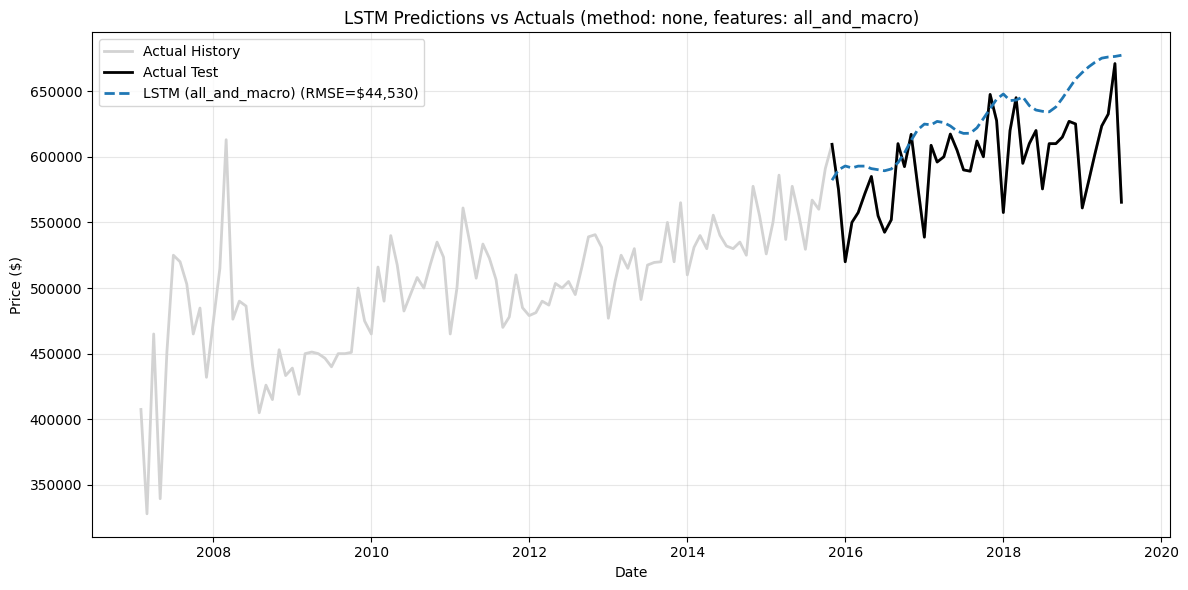

Computing SHAP values...


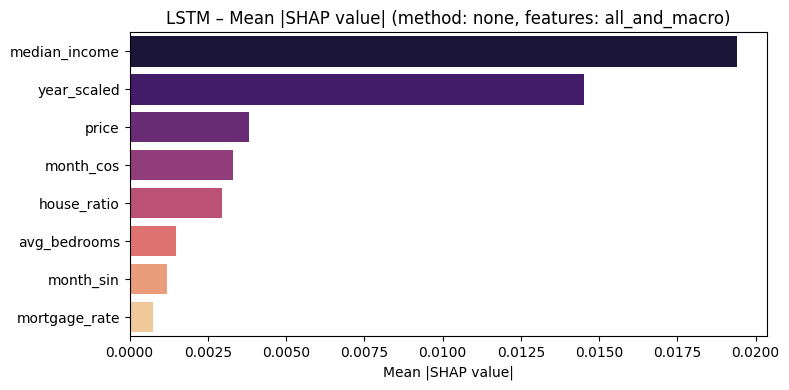

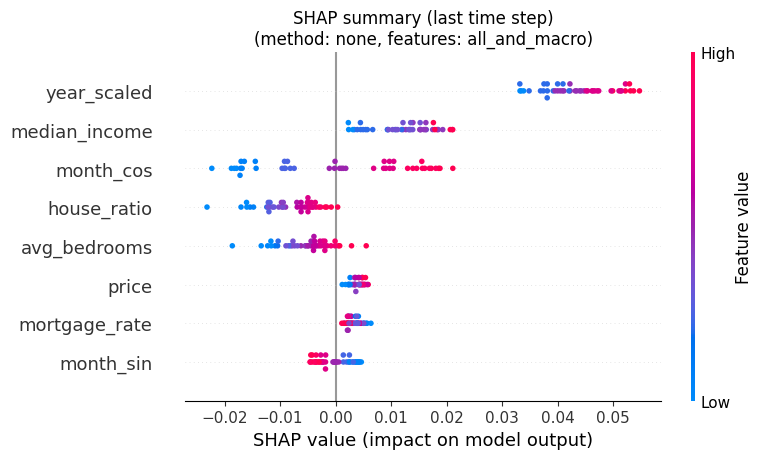

In [ ]:
lstm_evaluation_pipeline2(
    df,
    #feature sets only all_and_macro of FEATURE_SETS
    feature_sets = FEATURE_SETS,
    types_of_outlier=("log_transform",),  # make this a single-element tuple
    train_size=train_size,
    param_grid=param_grid,
    seq_len=11, #11 is very nice
    gridsearch=False,
    plot=True,
    explain=True,
)

### SARIMAX

**SARIMAX + deterministic seasonality**

SARIMAX already captures stochastic seasonal autocorrelation via its seasonal AR/MA terms `(P,D,Q)[m=12]`.  
Adding `month_sin`, `month_cos` as exogenous regressors on top introduces *deterministic* seasonality — a fixed, repeatable within-year shape — which is complementary rather than redundant.  
`year_scaled` captures the long-run price trend as a smooth exogenous slope.

We also fix two issues from the original notebook:
1. **`RMSE: $inf`** — caused by numerical instability in the covariance matrix. Fixed by using `method='lbfgs'` and `cov_type='robust'`.
2. **Order selection** — `auto_arima` is re-run on the expanded exogenous set so the optimal order reflects the new features.

In [62]:
%pip install pmdarima

Defaulting to user installation because normal site-packages is not writeable
  Using cached pmdarima-2.1.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.5 kB)
  Using cached cython-3.2.4-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (7.5 kB)
Using cached pmdarima-2.1.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (689 kB)
Using cached cython-3.2.4-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (3.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pmdarima]1/2 [pmdarima]
Note: you may need to restart the kernel to use updated packages.


In [63]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

In [71]:
FEATURE_SETS = {
    # SARIMAX already handles seasonality via its (P,D,Q)[12] terms,
    # so month_sin/month_cos/year_scaled are NOT included as exogenous regressors.
    # Only truly exogenous economic/market variables are used.

    "all_and_macro": [
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "mortgage_rate",
        "median_income",
    ],

}


In [82]:

FEATURE_SETS = {
    # SARIMAX already handles seasonality via its (P,D,Q)[12] terms,
    # so month_sin/month_cos/year_scaled are NOT included as exogenous regressors.
    # Only truly exogenous economic/market variables are used.

    "all_and_macro": [
        "avg_bedrooms",
        "house_ratio",
        #"sales_count",
        "mortgage_rate",
        "median_income",
    ],


    }

def calculate_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

def run_sarimax_experiments(
    outlier_modes=("none", "remove", "log_transform"),
    plot=True,
    explain=True,
    feature_sets=FEATURE_SETS,
    train_frac=train_size,
):

    results = {}

    for outlier_mode in outlier_modes:
        print(f"\n=== SARIMAX | outlier method: {outlier_mode} ===")

        df_cleaned, monthly, monthly_df_cleaned = pipeline(
            df, type_of_outlier=outlier_mode, plotting=False
        )
        df_monthly = add_seasonality_features(monthly_df_cleaned).asfreq("MS").dropna()

        split_idx = int(len(df_monthly) * train_frac)
        train = df_monthly.iloc[:split_idx]
        test = df_monthly.iloc[split_idx:]

        y_train = train["price"]
        y_test = test["price"]

        for feat_name, exog_cols in feature_sets.items():
            print(f"\n--- SARIMAX | outlier: {outlier_mode} | features: {feat_name} ---")

            X_train = train[exog_cols]
            X_test = test[exog_cols]

            print(f"Train: {len(train)} | Test: {len(test)}")

            auto_model = auto_arima(
                y=y_train,
                exogenous=X_train,
                seasonal=True,
                m=12,
                trace=False,
                error_action="ignore",
                suppress_warnings=True,
                stepwise=True,
                max_p=3,
                max_q=3,
                max_P=2,
                max_Q=2,
                information_criterion="aic",
            )
            print(
                f"Best ARIMA order: {auto_model.order}  |  Seasonal: {auto_model.seasonal_order}"
            )

            sarimax_model = SARIMAX(
                endog=y_train,
                exog=X_train,
                order=auto_model.order,
                seasonal_order=auto_model.seasonal_order,
                trend="n",
                enforce_stationarity=True,
                enforce_invertibility=True,
            )
            sarimax_fit = sarimax_model.fit(disp=False, method="lbfgs", cov_type="robust")
            print(sarimax_fit.summary())

            forecast = sarimax_fit.predict(
                start=test.index[0], end=test.index[-1], exog=X_test
            )

            if outlier_mode == "log_transform":
                actual_plot = np.exp(y_test)
                forecast_plot = np.exp(forecast)
                train_plot = np.exp(y_train)
            else:
                actual_plot = y_test
                forecast_plot = forecast
                train_plot = y_train

            rmse_sarimax = calculate_rmse(actual_plot.values, forecast_plot.values)
            print(f"SARIMAX RMSE ({feat_name}): ${rmse_sarimax:,.2f}")

            if outlier_mode not in results:
                results[outlier_mode] = {}
            results[outlier_mode][feat_name] = {
                "model": sarimax_fit,
                "rmse": rmse_sarimax,
                "forecast": forecast_plot,
                "actual": actual_plot,
                "train": train_plot,
                "auto_model": auto_model,
            }

            if plot:
                plt.figure(figsize=(12, 6))
                plt.plot(train.index, train_plot, color="lightblue", label="Train")
                plt.plot(test.index, actual_plot, color="black", label="Actual")
                plt.plot(
                    test.index,
                    forecast_plot,
                    color="tomato",
                    label=f"SARIMAX Forecast (RMSE=${int(rmse_sarimax):,})",
                    linewidth=2,
                )
                plt.title(f"SARIMAX Forecast vs Actual (method: {outlier_mode}, features: {feat_name})")
                plt.xlabel("Date")
                plt.ylabel("Price ($)")
                plt.legend()
                plt.grid(True, linestyle="--", alpha=0.4)
                plt.tight_layout()
                plt.savefig(f'./imgs/sarimax_forecast_{outlier_mode}_{feat_name}.png', dpi=150, bbox_inches='tight')
                plt.show()

            if explain:
                try:
                    coef = sarimax_fit.params[exog_cols]
                    ci = sarimax_fit.conf_int().loc[exog_cols]
                    colors = ["tomato" if v > 0 else "steelblue" for v in coef.values]

                    plt.figure(figsize=(8, 4))
                    plt.barh(
                        coef.index,
                        coef.values,
                        xerr=[
                            (coef - ci.iloc[:, 0]).values,
                            (ci.iloc[:, 1] - coef).values,
                        ],
                        color=colors,
                        capsize=4,
                    )
                    plt.axvline(0, color="black", linewidth=0.8)
                    plt.title(
                        f"SARIMAX Exogenous Coefficients (method: {outlier_mode}, features: {feat_name})"
                    )
                    plt.xlabel("Coefficient value")
                    plt.tight_layout()
                    plt.savefig(f'./imgs/sarimax_coefficients_{outlier_mode}_{feat_name}.png', dpi=150, bbox_inches='tight')
                    plt.show()
                except Exception as e:
                    print(f"Could not plot coefficients: {e}")

    return results


=== SARIMAX | outlier method: none ===

--- SARIMAX | outlier: none | features: all_and_macro ---
Train: 105 | Test: 45
Best ARIMA order: (2, 1, 0)  |  Seasonal: (1, 0, 1, 12)
                                      SARIMAX Results                                       
Dep. Variable:                                price   No. Observations:                  105
Model:             SARIMAX(2, 1, 0)x(1, 0, [1], 12)   Log Likelihood               -1212.809
Date:                              Wed, 11 Mar 2026   AIC                           2443.618
Time:                                      15:50:17   BIC                           2467.417
Sample:                                  02-01-2007   HQIC                          2453.260
                                       - 10-01-2015                                         
Covariance Type:                             robust                                         
                    coef    std err          z      P>|z|      [0.025      0.97

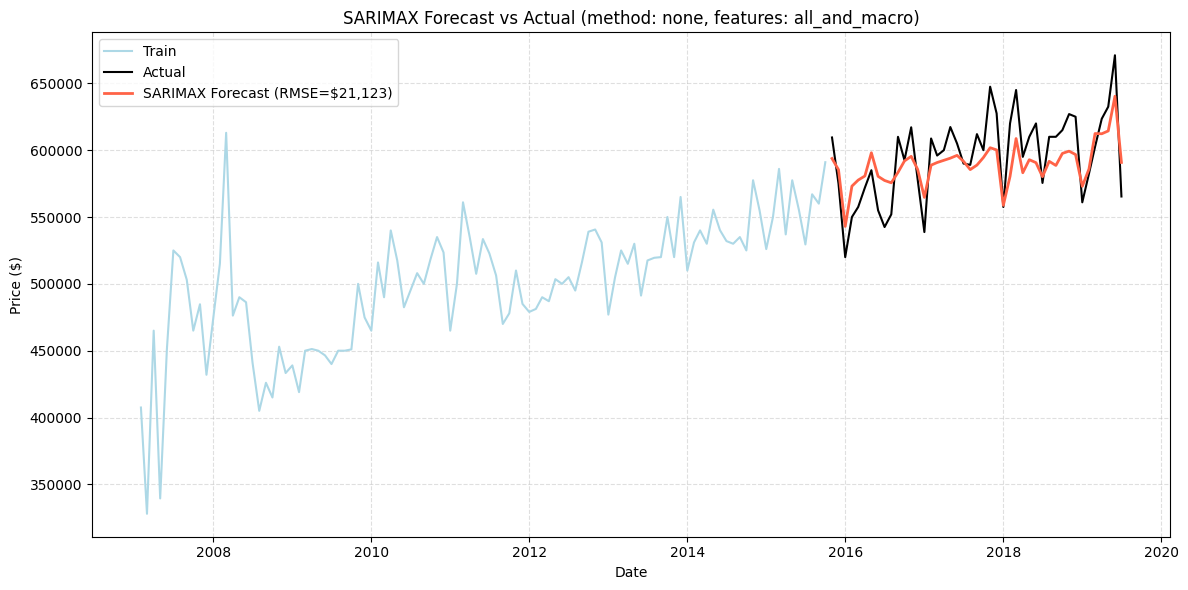

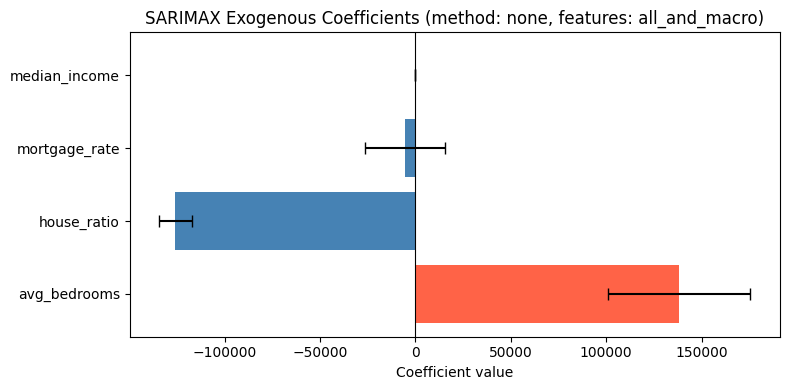

In [83]:
sarimax_results = run_sarimax_experiments(
    outlier_modes=("none",),
    plot=True,
    explain=True,
    train_frac=train_size,
    feature_sets = FEATURE_SETS,
)

In [158]:
monthly_df.head()

,price,house_ratio,avg_bedrooms,sales_count,mortgage_rate,median_income,month_sin,month_cos,year_scaled
month,,,,,,,,,
2007-02-01,407500.0,1.000000,3.500000,2,6.006667,73010.0,8.660254e-01,5.000000e-01,-1.613876
2007-03-01,328000.0,1.000000,3.333333,3,5.884000,73010.0,1.000000e+00,6.123234e-17,-1.613876
2007-04-01,432000.0,1.000000,3.500000,2,5.882500,73010.0,8.660254e-01,-5.000000e-01,-1.613876
2007-05-01,339500.0,1.000000,3.000000,2,5.968000,73010.0,5.000000e-01,-8.660254e-01,-1.613876
2007-06-01,451000.0,0.833333,3.333333,6,6.340000,73010.0,1.224647e-16,-1.000000e+00,-1.613876


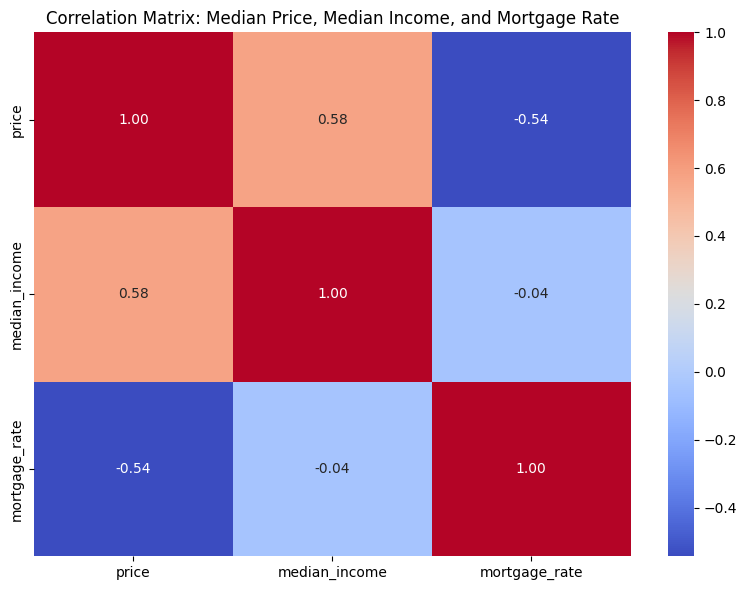

In [159]:
correlation_data = monthly_df[['price', 'median_income', 'mortgage_rate']]
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Median Price, Median Income, and Mortgage Rate')
plt.tight_layout()
plt.savefig('./imgs/macro_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

- Median Price and Median Income (0.58): There is a moderate positive correlation between median price and median income. This suggests that as the median income in an area increases, property prices tend to rise, which is an expected relationship in real estate markets.
- Median Price and Mortgage Rate (-0.54): We observe a moderate negative correlation between median price and mortgage rates. This indicates that as mortgage rates increase, property prices tend to decrease, and vice-versa. Higher mortgage rates make borrowing more expensive, which can reduce housing affordability and dampen demand.
- Median Income and Mortgage Rate (-0.04): There is a very weak, almost negligible, negative correlation between median income and mortgage rates. This implies that these two macroeconomic factors do not have a strong linear relationship with each other in this dataset.

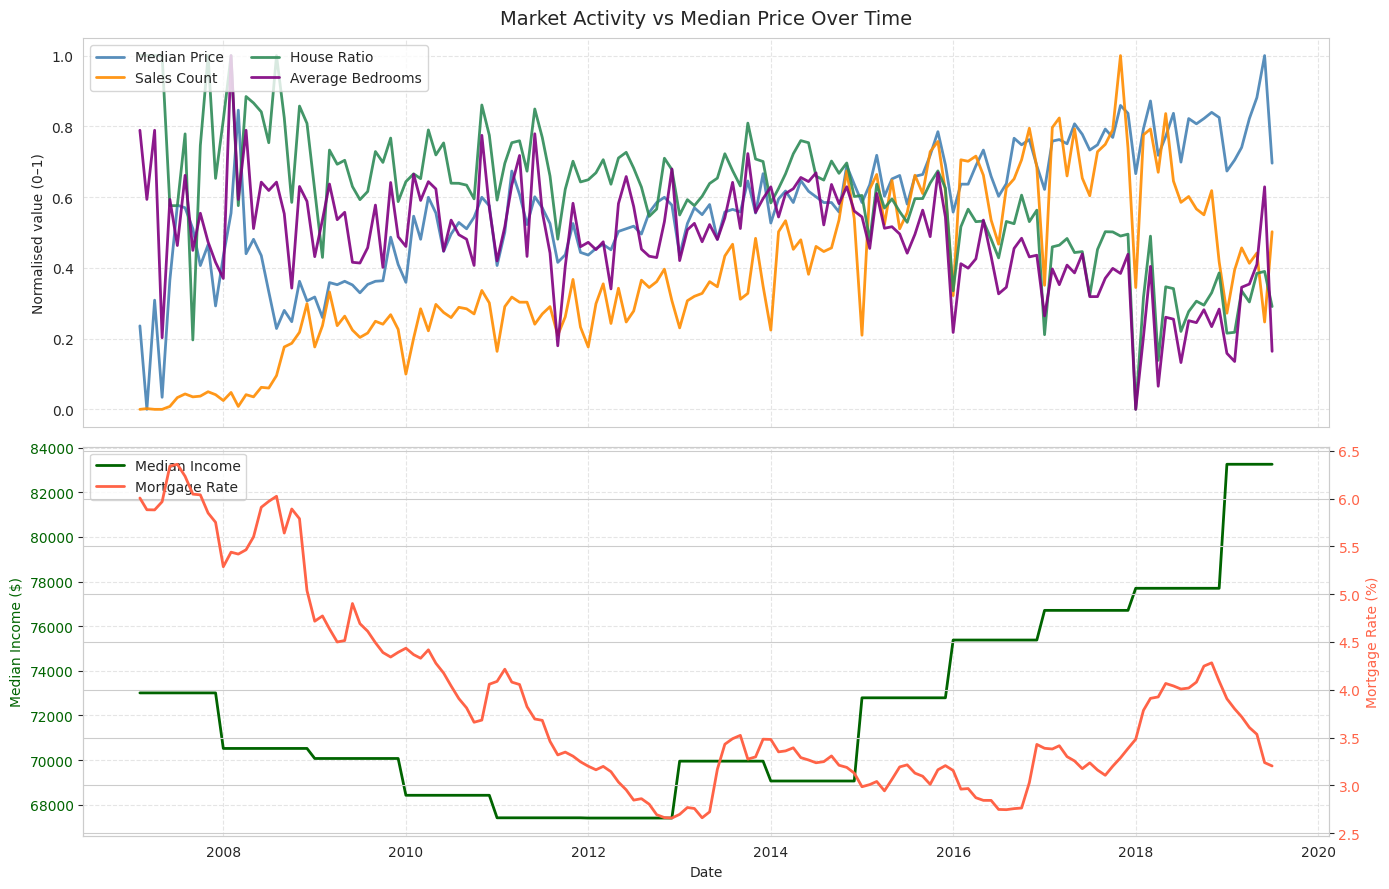

In [53]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# === Top panel: normalised series for comparability ===
ax1 = axes[0]
top_series = [
    ("price",        "steelblue", "Median Price"),
    ("sales_count",  "darkorange","Sales Count"),
    ("house_ratio",  "seagreen",  "House Ratio"),
    ("avg_bedrooms", "purple",    "Average Bedrooms"),
]

cols = [c[0] for c in top_series]
top_norm = (monthly_df[cols] - monthly_df[cols].min()) / (
    monthly_df[cols].max() - monthly_df[cols].min()
)

for col, color, label in top_series:
    ax1.plot(
        monthly_df.index,
        top_norm[col],
        color=color,
        label=label,
        linewidth=2,
        alpha=0.9,
    )

ax1.set_title("Market Activity vs Median Price Over Time", fontsize=14, pad=10)
ax1.set_ylabel("Normalised value (0–1)")
ax1.legend(loc="upper left", ncol=2, frameon=True)
ax1.grid(True, linestyle="--", alpha=0.5)

# === Bottom panel: Median Income and Mortgage Rate ===
ax2 = axes[1]
(line_income,) = ax2.plot(
    monthly_df.index,
    monthly_df["median_income"],
    color="darkgreen",
    label="Median Income",
    linewidth=2,
)
ax2.set_ylabel("Median Income ($)", color="darkgreen")
ax2.tick_params(axis="y", labelcolor="darkgreen")
ax2.grid(True, linestyle="--", alpha=0.5)

ax3 = ax2.twinx()
(line_rate,) = ax3.plot(
    monthly_df.index,
    monthly_df["mortgage_rate"],
    color="tomato",
    label="Mortgage Rate",
    linewidth=2,
)
ax3.set_ylabel("Mortgage Rate (%)", color="tomato")
ax3.tick_params(axis="y", labelcolor="tomato")

lines = [line_income, line_rate]
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc="upper left", frameon=True)

axes[1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("./imgs/macro_trends_over_time_with_sales.png", dpi=150, bbox_inches="tight")
plt.show()
